**Step 1**

In [ ]:
# Import required libraries
import yfinance as yf
import pandas as pd
import numpy as np

def download_etf_data(etf_symbols, start_date, end_date):
    """
    Downloads daily adjusted closing prices for specified ETFs using yfinance.

    Parameters:
        etf_symbols (list): List of ETF ticker symbols to download
        start_date (str): Start date for data collection (format: 'YYYY-MM-DD')
        end_date (str): End date for data collection (format: 'YYYY-MM-DD')

    Returns:
        pd.DataFrame: DataFrame containing daily adjusted closing prices for each ETF
    """
    # Download data from yfinance (focus on adjusted close prices for accuracy)
    # Adjusted close accounts for dividends, stock splits, and other corporate actions
    data = yf.download(
        tickers=etf_symbols,
        start=start_date,
        end=end_date,
        interval='1d',  # Daily frequency (required by the task)
        progress=False,  # Disable download progress bar for cleaner output
        auto_adjust=False,  # We'll explicitly use 'Adj Close' column
        actions=False  # Actions (dividends/splits) are already reflected in Adj Close
    )

    # Extract only the Adjusted Close prices (most relevant for return calculations)
    adj_close_prices = data['Adj Close'].dropna()  # Remove rows with missing values

    # Print summary information for verification
    print(f"Data download completed successfully!")
    print(f"Date range: {adj_close_prices.index.min().strftime('%Y-%m-%d')} to {adj_close_prices.index.max().strftime('%Y-%m-%d')}")
    print(f"Number of trading days: {len(adj_close_prices)}")
    print(f"ETFs included: {', '.join(adj_close_prices.columns.tolist())}")

    return adj_close_prices

if __name__ == "__main__":
    # Step 1: Define core parameters as per the task requirements
    # 5 ETFs representing different asset classes
    ETF_SYMBOLS = [
        "SPY",   # Equity (SPDR S&P500 ETF)
        "TLT",   # Fixed Income (iShares 20+ Year Treasury Bond ETF)
        "SHY",   # Cash-like (iShares 1-3 Year Treasury Bond ETF)
        "GLD",   # Precious metals (SPDR Gold Shares)
        "DBO"    # Crude Oil (Invesco DB Oil Fund)
    ]

    # Test sample period: January 1st, 2018 to December 30th, 2022
    TEST_START = "2018-01-01"
    TEST_END = "2022-12-30"

    # Step 2: Download test sample data
    test_sample_data = download_etf_data(ETF_SYMBOLS, TEST_START, TEST_END)

    # Step 3: Define and download training sample (discretionary split: 5 years before test period)
    # Rationale: Using 2013-2017 as training data provides sufficient history without overlap
    TRAIN_START = "2013-01-01"
    TRAIN_END = "2017-12-31"
    training_sample_data = download_etf_data(ETF_SYMBOLS, TRAIN_START, TRAIN_END)

    # Step 4: Optional - Define and download validation sample (6 months before test period)
    # Purpose: For hyperparameter tuning and avoiding overfitting
    VALID_START = "2017-07-01"
    VALID_END = "2017-12-31"
    validation_sample_data = download_etf_data(ETF_SYMBOLS, VALID_START, VALID_END)

    # Step 5: Save data to CSV for future use (optional but recommended)
    test_sample_data.to_csv("etf_test_sample_2018_2022.csv")
    training_sample_data.to_csv("etf_training_sample_2013_2017.csv")
    validation_sample_data.to_csv("etf_validation_sample_2017.csv")

    # Optional: Display first 5 rows of test sample to verify data structure
    print("\nSample of test data (first 5 rows):")
    print(test_sample_data.head())

Data download completed successfully!
Date range: 2018-01-02 to 2022-12-29
Number of trading days: 1258
ETFs included: DBO, GLD, SHY, SPY, TLT
Data download completed successfully!
Date range: 2013-01-02 to 2017-12-29
Number of trading days: 1259
ETFs included: DBO, GLD, SHY, SPY, TLT
Data download completed successfully!
Date range: 2017-07-03 to 2017-12-29
Number of trading days: 126
ETFs included: DBO, GLD, SHY, SPY, TLT

Sample of test data (first 5 rows):
Ticker           DBO         GLD        SHY         SPY         TLT
Date                                                               
2018-01-02  8.944057  125.150002  70.879150  237.909149  100.963882
2018-01-03  9.137156  124.820000  70.879150  239.413940  101.446671
2018-01-04  9.154711  125.459999  70.845352  240.423035  101.430573
2018-01-05  9.110826  125.330002  70.845352  242.025269  101.140915
2018-01-08  9.163488  125.309998  70.845352  242.467819  101.076553


Data range: 2018-01-02 to 2022-12-29
Trading days: 1258, ETFs: DBO, GLD, SHY, SPY, TLT

=== Summary Statistics (Daily Returns) ===
        Mean Return (%)  Volatility (%)  Sharpe Ratio (rfr=0%)  Skewness  \
Ticker                                                                     
DBO              0.0332          2.1855                 0.2415   -1.1256   
GLD              0.0238          0.9057                 0.4176   -0.3445   
SHY              0.0026          0.0882                 0.4652    0.0837   
SPY              0.0351          1.3638                 0.4081   -0.7804   
TLT             -0.0093          1.0162                -0.1453    0.1189   

        Kurtosis  Jarque-Bera p-value  
Ticker                                 
DBO       7.2558                  0.0  
GLD       3.6419                  0.0  
SHY       7.5154                  0.0  
SPY      11.2261                  0.0  
TLT       6.7335                  0.0  

=== Stationarity Test (Augmented Dickey-Fuller) ===

AD

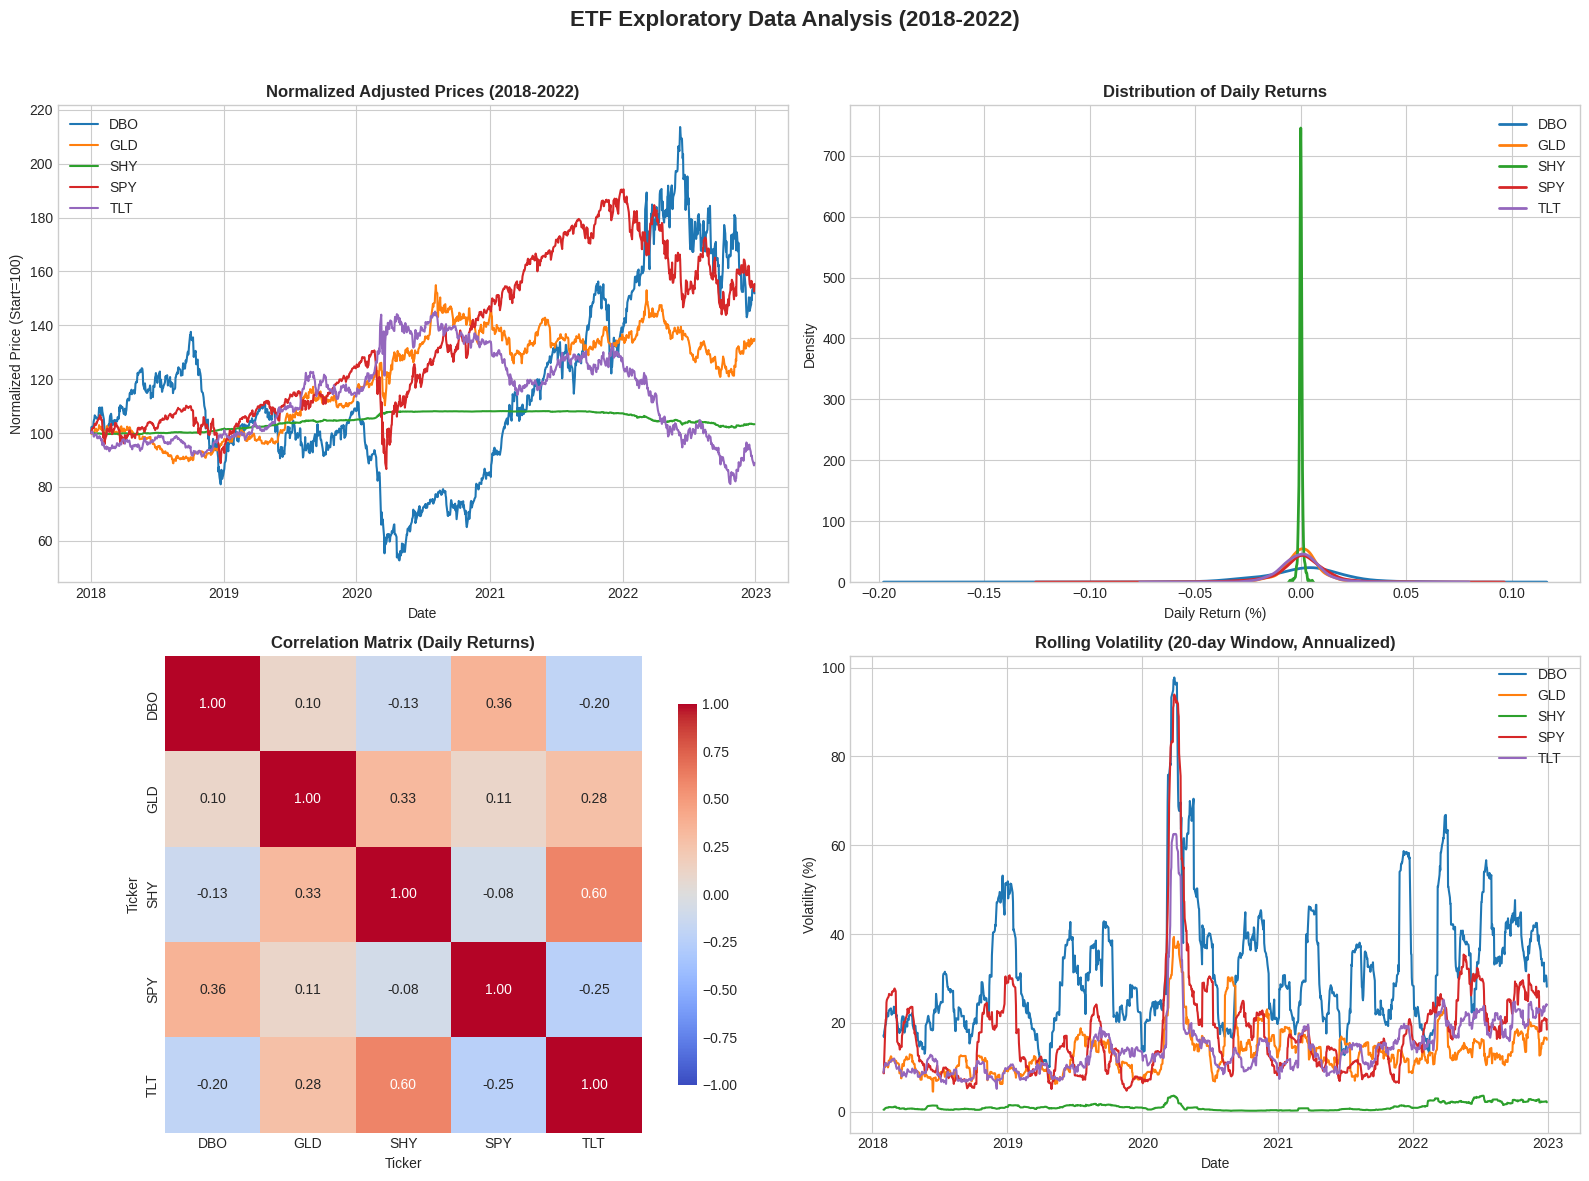

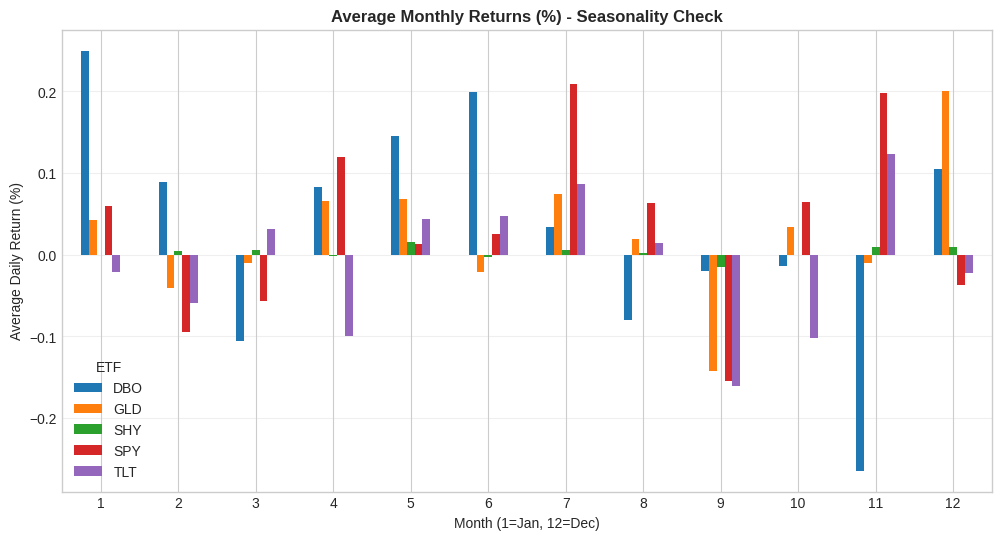

In [ ]:
# Import required libraries (extended for EDA/visualization)
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import seaborn as sns
from scipy import stats

# Set plot style and parameters for readability
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True

def download_etf_data(etf_symbols, start_date, end_date):
    """
    Downloads daily adjusted closing prices for specified ETFs using yfinance.

    Parameters:
        etf_symbols (list): List of ETF ticker symbols to download
        start_date (str): Start date for data collection (format: 'YYYY-MM-DD')
        end_date (str): End date for data collection (format: 'YYYY-MM-DD')

    Returns:
        pd.DataFrame: DataFrame containing daily adjusted closing prices for each ETF
    """
    data = yf.download(
        tickers=etf_symbols,
        start=start_date,
        end=end_date,
        interval='1d',
        progress=False,
        auto_adjust=False,
        actions=False
    )
    adj_close_prices = data['Adj Close'].dropna()

    # Print verification summary
    print(f"Data range: {adj_close_prices.index.min().strftime('%Y-%m-%d')} to {adj_close_prices.index.max().strftime('%Y-%m-%d')}")
    print(f"Trading days: {len(adj_close_prices)}, ETFs: {', '.join(adj_close_prices.columns)}")

    return adj_close_prices

def calculate_daily_returns(price_data):
    """Calculates daily logarithmic returns (more suitable for time-series analysis than simple returns)"""
    return np.log(price_data / price_data.shift(1)).dropna()

def summary_statistics(returns_data):
    """Generates key summary statistics for daily returns"""
    stats_df = pd.DataFrame({
        'Mean Return (%)': returns_data.mean() * 100,
        'Volatility (%)': returns_data.std() * 100,
        'Sharpe Ratio (rfr=0%)': returns_data.mean() / returns_data.std() * np.sqrt(252),  # Annualized
        'Skewness': returns_data.skew(),
        'Kurtosis': returns_data.kurtosis(),
        'Jarque-Bera p-value': [stats.jarque_bera(returns_data[etf])[1] for etf in returns_data.columns]
    })
    print("\n=== Summary Statistics (Daily Returns) ===")
    print(stats_df.round(4))
    return stats_df

def adf_stationarity_test(series, name):
    """Performs Augmented Dickey-Fuller test for stationarity"""
    result = adfuller(series)
    print(f"\nADF Test for {name}:")
    print(f"Test Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Critical Values (1%/5%/10%): {result[4]}")
    print(f"Stationary: {'YES' if result[1] < 0.05 else 'NO'} (p<0.05)")

def plot_price_series(price_data):
    """Plots normalized price time-series (to compare trends on same scale)"""
    # Normalize prices to 100 at start for better visual comparison
    normalized_prices = (price_data / price_data.iloc[0]) * 100

    plt.subplot(2, 2, 1)
    for etf in normalized_prices.columns:
        plt.plot(normalized_prices.index, normalized_prices[etf], label=etf, linewidth=1.5)
    plt.title('Normalized Adjusted Prices (2018-2022)', fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Normalized Price (Start=100)')
    plt.legend()
    plt.tight_layout()

def plot_returns_distribution(returns_data):
    """Plots histogram + KDE of daily returns (individual distribution)"""
    plt.subplot(2, 2, 2)
    for etf in returns_data.columns:
        sns.kdeplot(returns_data[etf], label=etf, linewidth=2)
    plt.title('Distribution of Daily Returns', fontweight='bold')
    plt.xlabel('Daily Return (%)')
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()

def plot_correlation_heatmap(returns_data):
    """Plots correlation matrix of daily returns (joint distribution)"""
    corr_matrix = returns_data.corr()

    plt.subplot(2, 2, 3)
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        fmt='.2f',
        square=True,
        cbar_kws={'shrink': 0.8}
    )
    plt.title('Correlation Matrix (Daily Returns)', fontweight='bold')
    plt.tight_layout()

def plot_volatility_clustering(returns_data):
    """Plots rolling volatility to show clustering (time-series characteristic)"""
    # 20-day rolling window (approx 1 month of trading days)
    rolling_vol = returns_data.rolling(window=20).std() * np.sqrt(252) * 100  # Annualized

    plt.subplot(2, 2, 4)
    for etf in rolling_vol.columns:
        plt.plot(rolling_vol.index, rolling_vol[etf], label=etf, linewidth=1.5)
    plt.title('Rolling Volatility (20-day Window, Annualized)', fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Volatility (%)')
    plt.legend()
    plt.tight_layout()

if __name__ == "__main__":
    # ----------------------
    # Step 1: Download Data (Reused from previous script)
    # ----------------------
    ETF_SYMBOLS = ["SPY", "TLT", "SHY", "GLD", "DBO"]
    TEST_START = "2018-01-01"
    TEST_END = "2022-12-30"

    # Download test sample data (focus EDA on test period as per task)
    price_data = download_etf_data(ETF_SYMBOLS, TEST_START, TEST_END)

    # Calculate daily returns (core for EDA beyond price trends)
    returns_data = calculate_daily_returns(price_data)

    # ----------------------
    # Step 2: Core EDA
    # ----------------------
    # 1. Summary Statistics
    summary_stats = summary_statistics(returns_data)

    # 2. Stationarity Test (ADF Test)
    print("\n=== Stationarity Test (Augmented Dickey-Fuller) ===")
    for etf in returns_data.columns:
        adf_stationarity_test(returns_data[etf], etf)

    # 3. Visualizations (4 key plots in one figure)
    plt.figure(figsize=(16, 12))

    plot_price_series(price_data)          # Trend comparison (normalized)
    plot_returns_distribution(returns_data)# Individual return distributions
    plot_correlation_heatmap(returns_data) # Joint distribution (correlations)
    plot_volatility_clustering(returns_data)# Time-series volatility clustering

    plt.suptitle('ETF Exploratory Data Analysis (2018-2022)', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust for suptitle
    plt.savefig('etf_eda_2018_2022.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ----------------------
    # Optional: Seasonality Check (Monthly Returns)
    # ----------------------
    returns_data['Month'] = returns_data.index.month
    monthly_returns = returns_data.groupby('Month').mean() * 100

    plt.figure(figsize=(12, 6))
    monthly_returns.plot(kind='bar', ax=plt.gca())
    plt.title('Average Monthly Returns (%) - Seasonality Check', fontweight='bold')
    plt.xlabel('Month (1=Jan, 12=Dec)')
    plt.ylabel('Average Daily Return (%)')
    plt.xticks(rotation=0)
    plt.legend(title='ETF')
    plt.grid(axis='y', alpha=0.3)
    plt.savefig('etf_monthly_seasonality.png', dpi=300, bbox_inches='tight')
    plt.show()

**Step 2**

=== Loading and Preprocessing Data ===
Data range: 2018-01-02 to 2022-12-29
Trading days: 1258, ETFs: DBO, GLD, SHY, SPY, TLT
Daily returns data shape: (1257, 5)
Target data shape: (1232, 5)
Target variable: 25-day ahead cumulative log return

=== Starting LSTM Model Training for All ETFs ===

=== Training LSTM Model for SPY ===
Aligned data for SPY: 1232 samples (features = targets)
Sequence creation successful for SPY: X=(1202, 30, 1), y=(1202, 1)
Train set: X=(961, 30, 1), y=(961, 1); Validation set: X=(241, 30, 1), y=(241, 1)


Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_74 (LSTM)                  │ (None, 30, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_74 (Dropout)            │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_75 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_75 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - loss: 0.0269 - mean_absolute_error: 0.1235 - val_loss: 0.0192 - val_mean_absolute_error: 0.1178
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0088 - mean_absolute_error: 0.0716 - val_loss: 0.0109 - val_mean_absolute_error: 0.0861
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0058 - mean_absolute_error: 0.0574 - val_loss: 0.0111 - val_mean_absolute_error: 0.0876
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0054 - mean_absolute_error: 0.0538 - val_loss: 0.0130 - val_mean_absolute_error: 0.0963
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - loss: 0.0049 - mean_absolute_error: 0.0517 - val_loss: 0.0106 - val_mean_absolute_error: 0.0875
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0043 - mean_absolute_error: 0.0481 - val_loss: 0.0127 - val_mean_absolute_error: 0.0959
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0045 - mean_absolute_error: 0.0490 - val_loss


Validation Metrics for SPY:
RMSE: 0.083260 | MAE: 0.071991 | R² Score: -0.5809


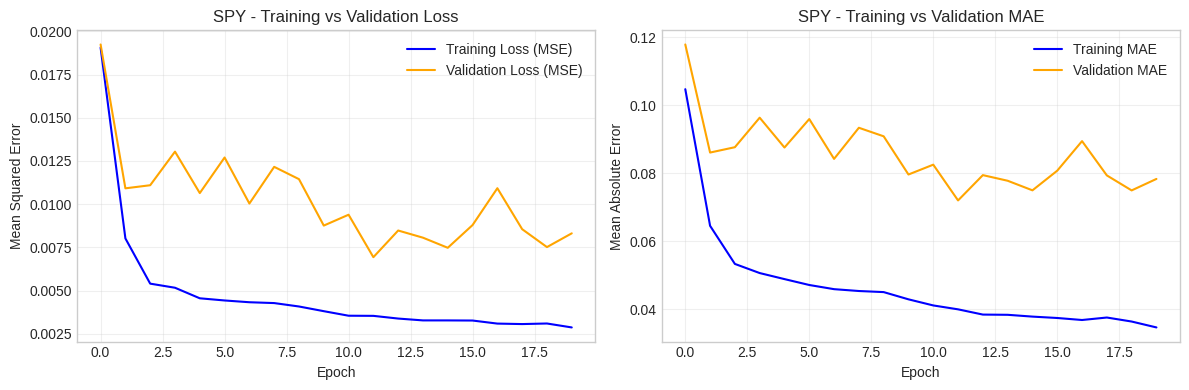

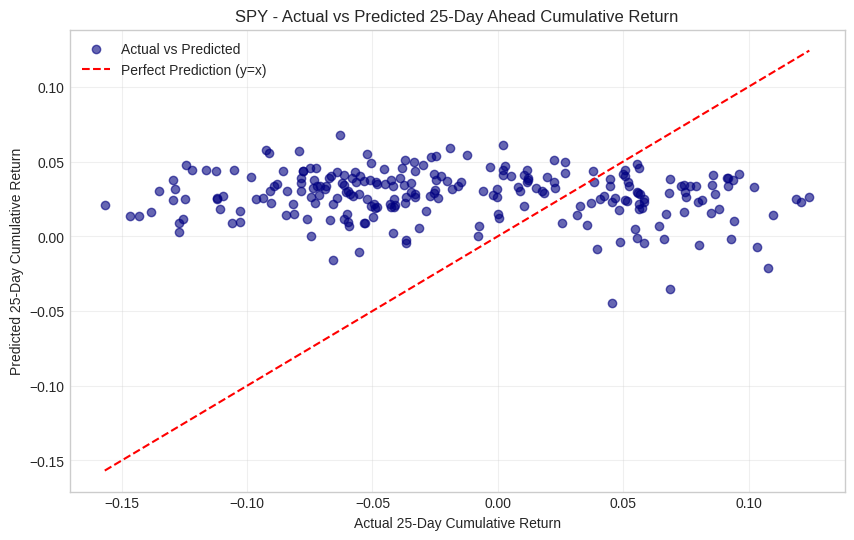


=== Training LSTM Model for TLT ===
Aligned data for TLT: 1232 samples (features = targets)
Sequence creation successful for TLT: X=(1202, 30, 1), y=(1202, 1)
Train set: X=(961, 30, 1), y=(961, 1); Validation set: X=(241, 30, 1), y=(241, 1)


Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_76 (LSTM)                  │ (None, 30, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_76 (Dropout)            │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_77 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_77 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - loss: 0.0266 - mean_absolute_error: 0.1191 - val_loss: 0.0052 - val_mean_absolute_error: 0.0582
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0040 - mean_absolute_error: 0.0505 - val_loss: 0.0048 - val_mean_absolute_error: 0.0590
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0030 - mean_absolute_error: 0.0432 - val_loss: 0.0042 - val_mean_absolute_error: 0.0511
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0024 - mean_absolute_error: 0.0397 - val_loss: 0.0041 - val_mean_absolute_error: 0.0488
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 0.0023 - mean_absolute_error: 0.0377 - val_loss: 0.0039 - val_mean_absolute_error: 0.0462
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0022 - mean_absolute_error: 0.0372 - val_loss: 0.0038 - val_mean_absolute_error: 0.0455
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0021 - mean_absolute_error: 0.0359 - val_los


Validation Metrics for TLT:
RMSE: 0.061720 | MAE: 0.045475 | R² Score: -0.0880


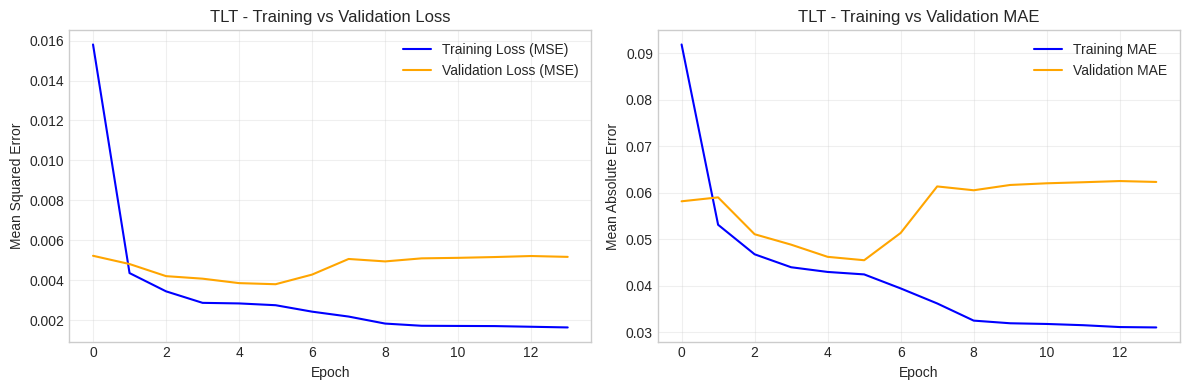

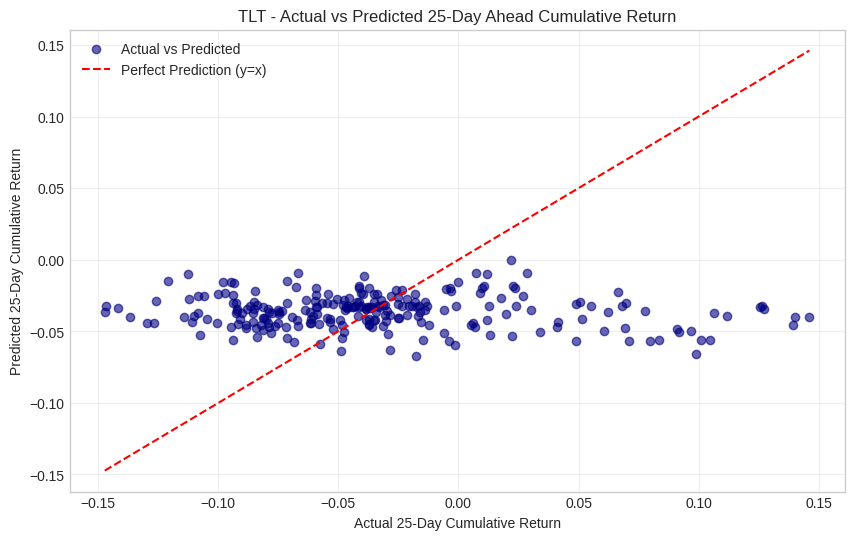


=== Training LSTM Model for SHY ===
Aligned data for SHY: 1232 samples (features = targets)
Sequence creation successful for SHY: X=(1202, 30, 1), y=(1202, 1)
Train set: X=(961, 30, 1), y=(961, 1); Validation set: X=(241, 30, 1), y=(241, 1)


Model: "sequential_39"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_78 (LSTM)                  │ (None, 30, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_78 (Dropout)            │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_79 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_79 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0109 - mean_absolute_error: 0.0807 - val_loss: 0.0013 - val_mean_absolute_error: 0.0326
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0014 - mean_absolute_error: 0.0277 - val_loss: 2.4584e-04 - val_mean_absolute_error: 0.0123
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 5.6310e-04 - mean_absolute_error: 0.0185 - val_loss: 1.1428e-04 - val_mean_absolute_error: 0.0090
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 3.9743e-04 - mean_absolute_error: 0.0147 - val_loss: 1.6255e-04 - val_mean_absolute_error: 0.0105
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 2.1739e-04 - mean_absolute_error: 0.0110 - val_loss: 1.0638e-04 - val_mean_absolute_error: 0.0082
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 1.6615e-04 - mean_absolute_error: 0.0085 - val_loss: 7.6776e-05 - val_mean_absolute_error: 0.0072
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 1.1373e-04 


Validation Metrics for SHY:
RMSE: 0.008497 | MAE: 0.007179 | R² Score: -0.5149


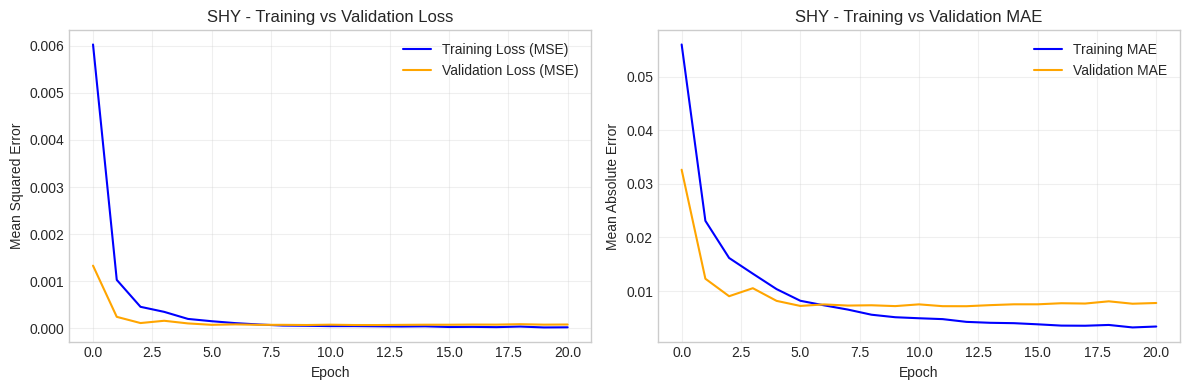

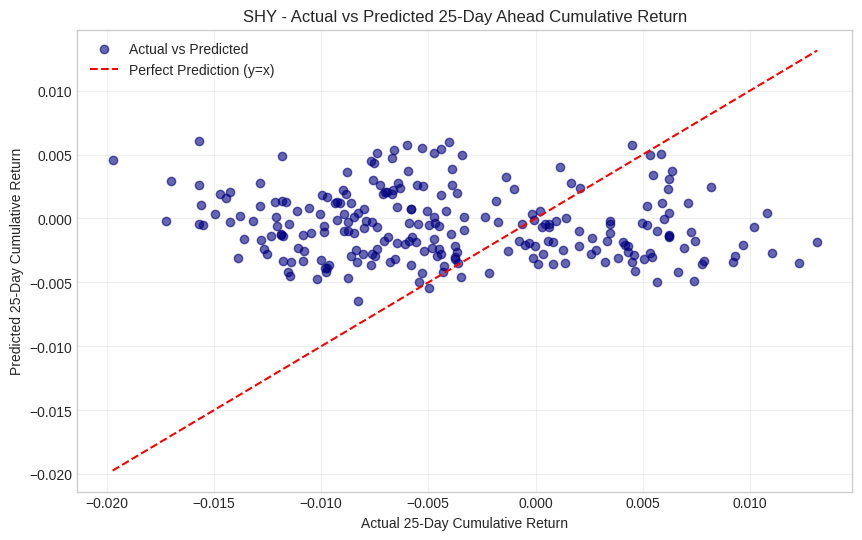


=== Training LSTM Model for GLD ===
Aligned data for GLD: 1232 samples (features = targets)
Sequence creation successful for GLD: X=(1202, 30, 1), y=(1202, 1)
Train set: X=(961, 30, 1), y=(961, 1); Validation set: X=(241, 30, 1), y=(241, 1)


Model: "sequential_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_80 (LSTM)                  │ (None, 30, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_80 (Dropout)            │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_81 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_81 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - loss: 0.0325 - mean_absolute_error: 0.1366 - val_loss: 0.0070 - val_mean_absolute_error: 0.0695
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0044 - mean_absolute_error: 0.0518 - val_loss: 0.0021 - val_mean_absolute_error: 0.0372
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0022 - mean_absolute_error: 0.0362 - val_loss: 0.0023 - val_mean_absolute_error: 0.0385
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 0.0015 - mean_absolute_error: 0.0301 - val_loss: 0.0021 - val_mean_absolute_error: 0.0372
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 0.0014 - mean_absolute_error: 0.0296 - val_loss: 0.0020 - val_mean_absolute_error: 0.0367
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.0014 - mean_absolute_error: 0.0292 - val_loss: 0.0020 - val_mean_absolute_error: 0.0367
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - loss: 0.0014 - mean_absolute_error: 0.0295 - val_los


Validation Metrics for GLD:
RMSE: 0.045170 | MAE: 0.036677 | R² Score: -0.0273


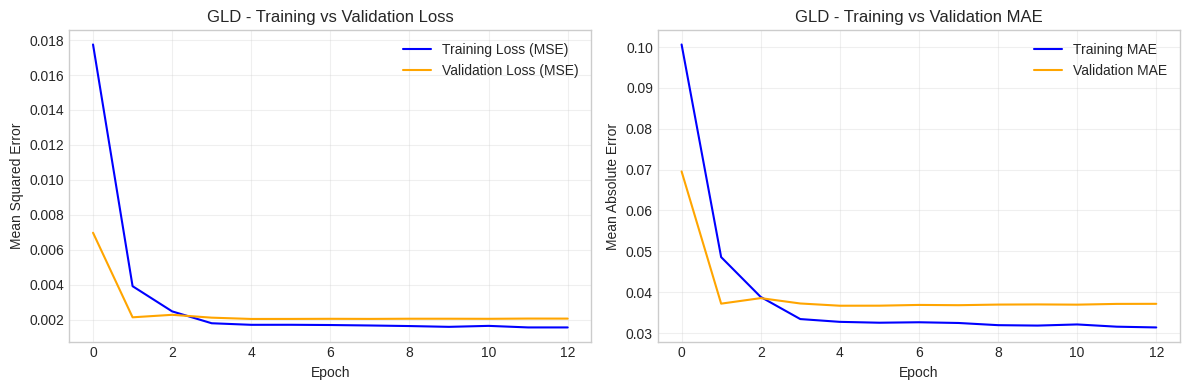

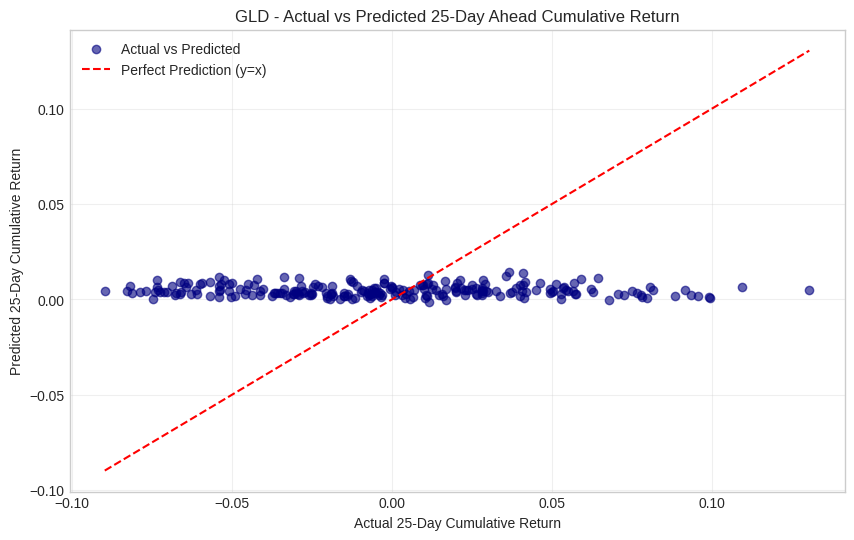


=== Training LSTM Model for DBO ===
Aligned data for DBO: 1232 samples (features = targets)
Sequence creation successful for DBO: X=(1202, 30, 1), y=(1202, 1)
Train set: X=(961, 30, 1), y=(961, 1); Validation set: X=(241, 30, 1), y=(241, 1)


Model: "sequential_41"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_82 (LSTM)                  │ (None, 30, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_82 (Dropout)            │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_83 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_83 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - loss: 0.0210 - mean_absolute_error: 0.1052 - val_loss: 0.0160 - val_mean_absolute_error: 0.1001
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 0.0119 - mean_absolute_error: 0.0818 - val_loss: 0.0205 - val_mean_absolute_error: 0.1162
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.0111 - mean_absolute_error: 0.0770 - val_loss: 0.0136 - val_mean_absolute_error: 0.0973
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.0112 - mean_absolute_error: 0.0752 - val_loss: 0.0118 - val_mean_absolute_error: 0.0888
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0109 - mean_absolute_error: 0.0792 - val_loss: 0.0114 - val_mean_absolute_error: 0.0894
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0111 - mean_absolute_error: 0.0773 - val_loss: 0.0108 - val_mean_absolute_error: 0.0868
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.0108 - mean_absolute_error: 0.0776 - val_los


Validation Metrics for DBO:
RMSE: 0.103687 | MAE: 0.086790 | R² Score: -0.1114


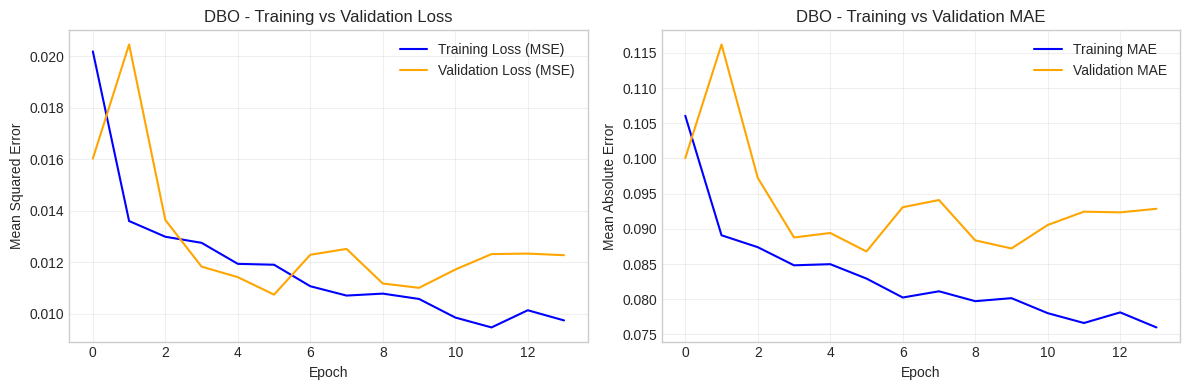

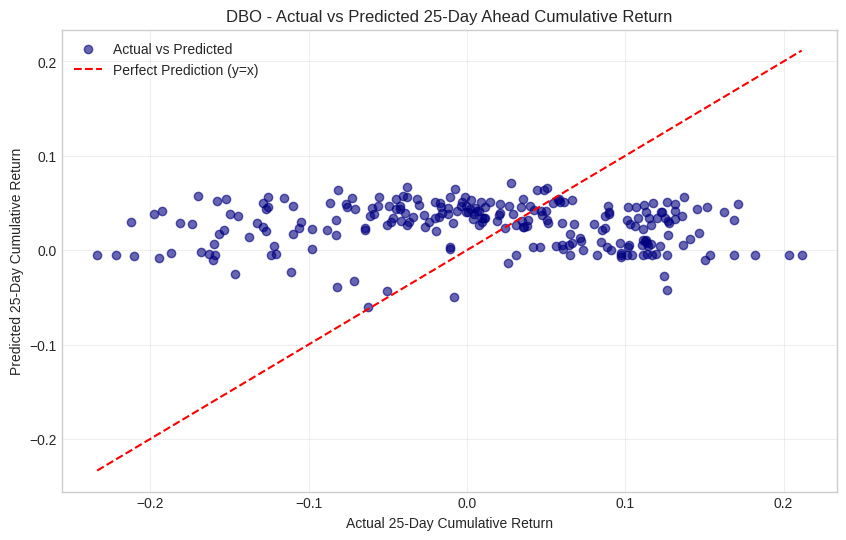


=== LSTM Model Performance Summary (All ETFs) ===
   ETF    RMSE     MAE  R² Score
0  SPY  0.0833  0.0720   -0.5809
1  TLT  0.0617  0.0455   -0.0880
2  SHY  0.0085  0.0072   -0.5149
3  GLD  0.0452  0.0367   -0.0273
4  DBO  0.1037  0.0868   -0.1114


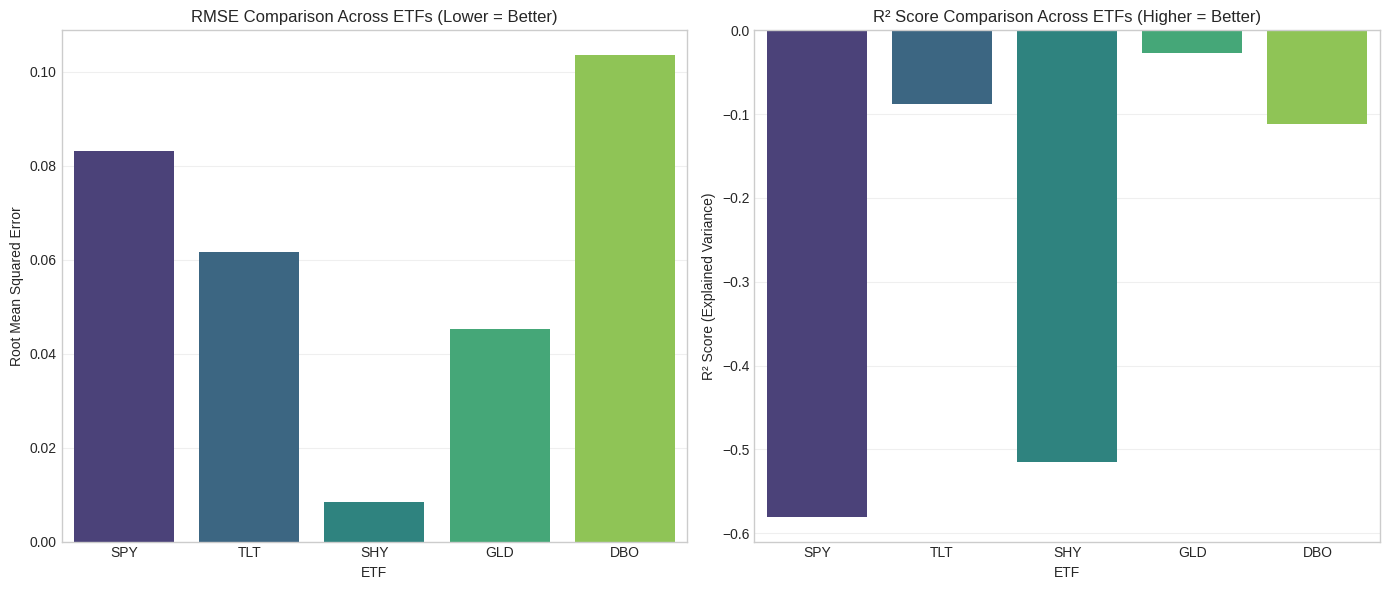

In [ ]:
# Import required libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure plot style for readability
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

# ----------------------
# Reusable Data Loading Functions
# ----------------------
def download_etf_data(etf_symbols, start_date, end_date):
    """
    Downloads daily adjusted closing prices for specified ETFs using yfinance.

    Parameters:
        etf_symbols (list): List of ETF ticker symbols
        start_date (str): Start date in 'YYYY-MM-DD' format
        end_date (str): End date in 'YYYY-MM-DD' format

    Returns:
        pd.DataFrame: DataFrame with adjusted closing prices (index: dates, columns: ETFs)
    """
    data = yf.download(
        tickers=etf_symbols,
        start=start_date,
        end=end_date,
        interval='1d',
        progress=False,
        auto_adjust=False,
        actions=False
    )
    adj_close_prices = data['Adj Close'].dropna()
    print(f"Data range: {adj_close_prices.index.min().strftime('%Y-%m-%d')} to {adj_close_prices.index.max().strftime('%Y-%m-%d')}")
    print(f"Trading days: {len(adj_close_prices)}, ETFs: {', '.join(adj_close_prices.columns)}")
    return adj_close_prices

def calculate_daily_returns(price_data):
    """
    Calculates daily logarithmic returns (more suitable for time-series analysis than simple returns).

    Parameters:
        price_data (pd.DataFrame): Adjusted closing prices of ETFs

    Returns:
        pd.DataFrame: Daily log returns (index: dates, columns: ETFs)
    """
    return np.log(price_data / price_data.shift(1)).dropna()

# ----------------------
# Target Variable & Sequence Creation (FIXED LOGIC)
# ----------------------
def create_target_variable(returns_data, target_horizon=25):
    """
    Creates target variable: 25-day ahead cumulative log return for each ETF.
    Target = Sum of returns from t+1 to t+25 (cumulative return over next 25 trading days)

    Parameters:
        returns_data (pd.DataFrame): Daily log returns of ETFs
        target_horizon (int): Number of days ahead to predict cumulative return (default: 25)

    Returns:
        pd.DataFrame: 25-day ahead cumulative returns (index: dates, columns: ETFs)
    """
    targets = {}
    for etf in returns_data.columns:
        # Calculate rolling cumulative return for future 'target_horizon' days
        cumulative_future_return = returns_data[etf].rolling(window=target_horizon).sum().shift(-target_horizon)
        targets[etf] = cumulative_future_return
    return pd.DataFrame(targets).dropna()

def create_lstm_sequences(returns_data, target_data, etf, lag_window=30):
    """
    Creates properly aligned input sequences (X) and target values (y) for LSTM training.
    FIXED: Ensures 1:1 mapping between input sequences and target values (no cardinality mismatch)

    Parameters:
        returns_data (pd.DataFrame): Daily log returns of all ETFs
        target_data (pd.DataFrame): 25-day ahead cumulative returns of all ETFs
        etf (str): Specific ETF ticker to create sequences for
        lag_window (int): Number of past days to use as input features (default: 30)

    Returns:
        tuple: (X, y, scaler)
            X: 3D array of input sequences (shape: [n_samples, lag_window, 1])
            y: 2D array of target values (shape: [n_samples, 1])
            scaler: StandardScaler fitted on the input features (for inference)
    """
    # Step 1: Align features (past returns) and target (25-day ahead return) by date
    # Use inner join to ensure only dates with both features and targets are kept
    features = returns_data[[etf]].rename(columns={etf: 'daily_return'})
    targets = target_data[[etf]].rename(columns={etf: 'cumulative_25d_return'})
    aligned_data = features.join(targets, how='inner').dropna()

    # Step 2: Validate data sufficiency
    if len(aligned_data) <= lag_window:
        raise ValueError(
            f"Insufficient data for {etf}: Aligned data length ({len(aligned_data)}) "
            f"must be greater than lag window ({lag_window})"
        )

    # Step 3: Extract raw features and targets (guaranteed to have same length)
    X_raw = aligned_data['daily_return'].values  # Shape: (n_aligned_samples,)
    y = aligned_data['cumulative_25d_return'].values  # Shape: (n_aligned_samples,)
    print(f"Aligned data for {etf}: {len(X_raw)} samples (features = targets)")

    # Step 4: Standardize features (critical for neural network stability)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw.reshape(-1, 1))  # Reshape to 2D for scaler: (n_samples, 1)

    # Step 5: Create sliding window sequences (core fixed logic)
    X_sequences = []
    # Loop to create sequences: each sequence = [t-lag_window+1, ..., t] -> predicts target at t+1
    for i in range(lag_window - 1, len(X_scaled) - 1):
        # Extract window of past 'lag_window' days of scaled returns
        sequence = X_scaled[i - lag_window + 1 : i + 1, 0]  # Shape: (lag_window,)
        X_sequences.append(sequence)

    # Step 6: Convert to LSTM-compatible shapes
    X = np.array(X_sequences).reshape(-1, lag_window, 1)  # (n_samples, time_steps, features)
    y = y[lag_window:].reshape(-1, 1)  # Align targets to sequences (skip first 'lag_window' targets)

    # Critical validation: Ensure X and y have matching number of samples
    assert len(X) == len(y), f"Sequence-target mismatch: X={len(X)} samples, y={len(y)} samples"
    print(f"Sequence creation successful for {etf}: X={X.shape}, y={y.shape}")

    return X, y, scaler

# ----------------------
# LSTM Model Architecture & Training
# ----------------------
def build_lstm_model(input_shape):
    """
    Builds a robust LSTM model with dropout regularization for time-series regression.

    Parameters:
        input_shape (tuple): Shape of input sequences (lag_window, 1)

    Returns:
        tf.keras.Model: Compiled LSTM model
    """
    model = Sequential([
        # First LSTM layer: captures short-term temporal dependencies
        LSTM(units=128, return_sequences=True, input_shape=input_shape, kernel_initializer='he_uniform'),
        Dropout(0.15),  # Reduce overfitting by randomly dropping 20% of neurons

        # Second LSTM layer: captures long-term temporal dependencies
        LSTM(units=64, return_sequences=False, kernel_initializer='he_uniform'),
        Dropout(0.15),

        # Dense layers for non-linear transformation
        Dense(units=32, activation='relu', kernel_initializer='he_uniform'),
        Dense(units=1)  # Output layer: no activation (regression task)
    ])

    # Compile model with Adam optimizer and MSE loss (standard for regression)
    model.compile(
        optimizer=Adam(learning_rate=0.001, clipnorm=1.0),  # Clipnorm prevents exploding gradients
        loss='mean_squared_error',
        metrics=['mean_absolute_error']
    )

    return model

def train_etf_lstm(etf, returns_data, target_data, lag_window=30, epochs=30, batch_size=32):
    """
    End-to-end training pipeline for single ETF LSTM model (25-day ahead return prediction).

    Parameters:
        etf (str): ETF ticker to train model for
        returns_data (pd.DataFrame): Daily log returns of all ETFs
        target_data (pd.DataFrame): 25-day ahead cumulative returns of all ETFs
        lag_window (int): Number of past days to use as input features
        epochs (int): Maximum number of training epochs
        batch_size (int): Batch size for gradient descent

    Returns:
        tuple: (model, history, X_val, y_val, y_pred_val)
            model: Trained LSTM model
            history: Training history (loss/metrics over epochs)
            X_val: Validation input sequences
            y_val: Actual validation targets
            y_pred_val: Predicted validation targets
    """
    print(f"\n=== Training LSTM Model for {etf} ===")

    # Step 1: Create properly aligned sequences
    X, y, scaler = create_lstm_sequences(returns_data, target_data, etf, lag_window)

    # Step 2: Time-based train-validation split (no shuffle to preserve temporal order)
    train_size = int(0.8 * len(X))
    # Ensure minimum validation samples (avoid edge cases with small datasets)
    if train_size >= len(X) - 10:
        train_size = len(X) - 20  # Reserve at least 20 samples for validation
        print(f"Adjusted train size to {train_size} (small dataset safeguard)")

    X_train, X_val = X[:train_size], X[train_size:]
    y_train, y_val = y[:train_size], y[train_size:]
    print(f"Train set: X={X_train.shape}, y={y_train.shape}; Validation set: X={X_val.shape}, y={y_val.shape}")

    # Step 3: Build model
    input_shape = (X_train.shape[1], X_train.shape[2])  # (lag_window, 1)
    model = build_lstm_model(input_shape)
    model.summary()

    # Step 4: Early stopping to prevent overfitting
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=8,  # Stop if validation loss doesn't improve for 8 epochs
        restore_best_weights=True,  # Revert to best model weights
        verbose=1
    )

    # Step 5: Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=1,
        shuffle=False  # No shuffling for time-series data
    )

    # Step 6: Evaluate model on validation set
    y_pred_val = model.predict(X_val, verbose=0)
    mse = mean_squared_error(y_val, y_pred_val)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_val, y_pred_val)
    r2 = r2_score(y_val, y_pred_val)

    print(f"\nValidation Metrics for {etf}:")
    print(f"RMSE: {rmse:.6f} | MAE: {mae:.6f} | R² Score: {r2:.4f}")

    # Step 7: Save trained model and scaler for future inference
    model.save(f'lstm_model_{etf}.h5')
    np.save(f'scaler_{etf}.npy', scaler)

    return model, history, X_val, y_val, y_pred_val

# ----------------------
# Visualization Functions
# ----------------------
def plot_training_history(history, etf):
    """
    Plots training vs validation loss and MAE over epochs.

    Parameters:
        history (tf.keras.callbacks.History): Training history object
        etf (str): ETF ticker for plot labeling
    """
    plt.figure(figsize=(12, 4))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss (MSE)', color='blue')
    plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='orange')
    plt.title(f'{etf} - Training vs Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot MAE
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mean_absolute_error'], label='Training MAE', color='blue')
    plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE', color='orange')
    plt.title(f'{etf} - Training vs Validation MAE')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Error')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'training_history_{etf}.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_prediction_results(y_val, y_pred_val, etf):
    """
    Plots scatter plot of actual vs predicted 25-day ahead returns.

    Parameters:
        y_val (np.array): Actual validation targets
        y_pred_val (np.array): Predicted validation targets
        etf (str): ETF ticker for plot labeling
    """
    plt.figure(figsize=(10, 6))
    plt.scatter(y_val, y_pred_val, alpha=0.6, color='navy', label='Actual vs Predicted')
    # Plot perfect prediction line (y=x)
    min_val = min(y_val.min(), y_pred_val.min())
    max_val = max(y_val.max(), y_pred_val.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction (y=x)')

    plt.title(f'{etf} - Actual vs Predicted 25-Day Ahead Cumulative Return')
    plt.xlabel('Actual 25-Day Cumulative Return')
    plt.ylabel('Predicted 25-Day Cumulative Return')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f'prediction_results_{etf}.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_performance_summary(all_metrics):
    """
    Plots bar charts comparing RMSE and R² across all ETF models.

    Parameters:
        all_metrics (list): List of dictionaries with 'ETF', 'RMSE', 'R² Score'
    """
    metrics_df = pd.DataFrame(all_metrics)

    plt.figure(figsize=(14, 6))

    # RMSE Comparison
    plt.subplot(1, 2, 1)
    sns.barplot(x='ETF', y='RMSE', data=metrics_df, palette='viridis')
    plt.title('RMSE Comparison Across ETFs (Lower = Better)')
    plt.ylabel('Root Mean Squared Error')
    plt.grid(axis='y', alpha=0.3)

    # R² Score Comparison
    plt.subplot(1, 2, 2)
    sns.barplot(x='ETF', y='R² Score', data=metrics_df, palette='viridis')
    plt.title('R² Score Comparison Across ETFs (Higher = Better)')
    plt.ylabel('R² Score (Explained Variance)')
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('model_performance_summary.png', dpi=300, bbox_inches='tight')
    plt.show()

# ----------------------
# Main Execution Pipeline
# ----------------------
if __name__ == "__main__":
    # Step 1: Configuration Parameters
    ETF_SYMBOLS = ["SPY", "TLT", "SHY", "GLD", "DBO"]  # 5 ETFs across asset classes
    TEST_START = "2018-01-01"                          # Start of test period
    TEST_END = "2022-12-30"                            # End of test period
    TARGET_HORIZON = 25                                # Predict 25-day ahead return
    LAG_WINDOW = 30                                    # Use past 90 days of returns as input
    EPOCHS = 30                                        # Max training epochs (reduced to prevent overfitting)
    BATCH_SIZE = 32                                    # Batch size for training

    # Step 2: Load and Preprocess Data
    print("=== Loading and Preprocessing Data ===")
    price_data = download_etf_data(ETF_SYMBOLS, TEST_START, TEST_END)
    returns_data = calculate_daily_returns(price_data)
    print(f"Daily returns data shape: {returns_data.shape}")

    # Create target variable (25-day ahead cumulative return)
    target_data = create_target_variable(returns_data, TARGET_HORIZON)
    print(f"Target data shape: {target_data.shape}")
    print(f"Target variable: {TARGET_HORIZON}-day ahead cumulative log return")

    # Step 3: Train LSTM Models for Each ETF
    print("\n=== Starting LSTM Model Training for All ETFs ===")
    all_models = {}  # Store trained models
    all_metrics = [] # Store performance metrics

    for etf in ETF_SYMBOLS:
        try:
            model, history, X_val, y_val, y_pred_val = train_etf_lstm(
                etf=etf,
                returns_data=returns_data,
                target_data=target_data,
                lag_window=LAG_WINDOW,
                epochs=EPOCHS,
                batch_size=BATCH_SIZE
            )

            # Save model and metrics
            all_models[etf] = model
            all_metrics.append({
                'ETF': etf,
                'RMSE': np.sqrt(mean_squared_error(y_val, y_pred_val)),
                'MAE': mean_absolute_error(y_val, y_pred_val),
                'R² Score': r2_score(y_val, y_pred_val)
            })

            # Generate visualizations
            plot_training_history(history, etf)
            plot_prediction_results(y_val, y_pred_val, etf)

        except Exception as e:
            print(f"\nError training model for {etf}: {str(e)}")
            continue

    # Step 4: Generate Performance Summary
    if all_metrics:
        print("\n=== LSTM Model Performance Summary (All ETFs) ===")
        metrics_df = pd.DataFrame(all_metrics).round(4)
        print(metrics_df)
        plot_performance_summary(all_metrics)
    else:
        print("\nNo models were trained successfully.")


=== Starting Out-of-Sample Testing (2023) ===

=== Out-of-Sample Testing for SPY ===


Data range: 2023-01-03 to 2023-12-29
Trading days: 250, ETFs: SPY
OOS Metrics for SPY:
RMSE: 0.043249 | MAE: 0.035607 | R² Score: -0.3432
OOS Samples: 194 | Target Range: -0.0571 to 0.1069


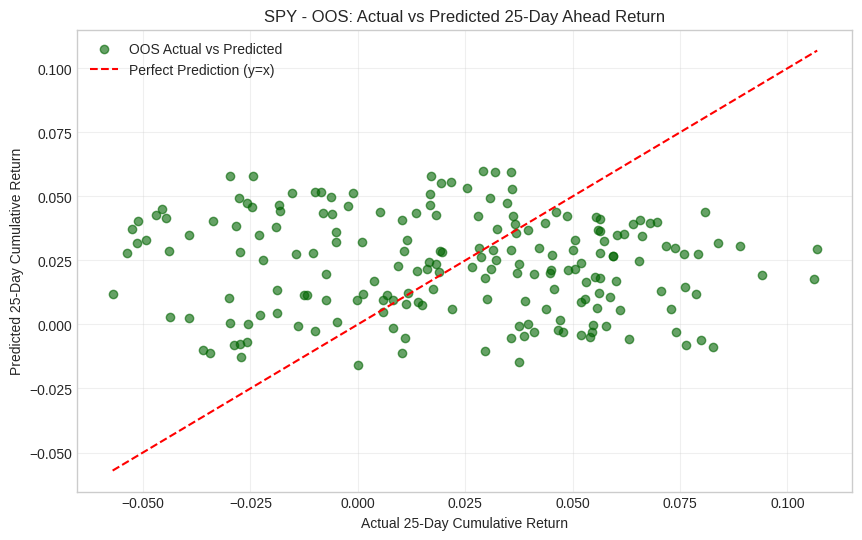


=== Out-of-Sample Testing for TLT ===
Data range: 2023-01-03 to 2023-12-29
Trading days: 250, ETFs: TLT


OOS Metrics for TLT:
RMSE: 0.066767 | MAE: 0.051310 | R² Score: -0.2875
OOS Samples: 194 | Target Range: -0.1247 to 0.1438


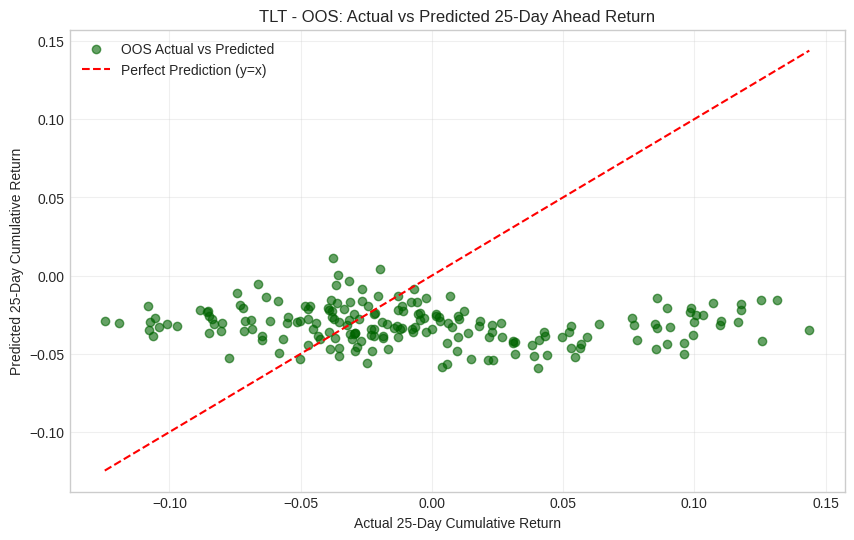


=== Out-of-Sample Testing for SHY ===
Data range: 2023-01-03 to 2023-12-29
Trading days: 250, ETFs: SHY


OOS Metrics for SHY:
RMSE: 0.008412 | MAE: 0.006135 | R² Score: -0.4188
OOS Samples: 194 | Target Range: -0.0114 to 0.0230


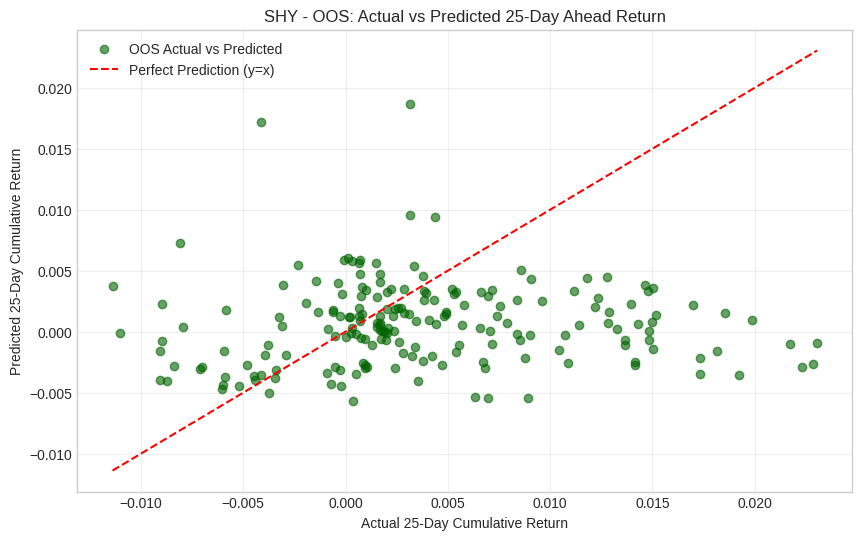


=== Out-of-Sample Testing for GLD ===
Data range: 2023-01-03 to 2023-12-29
Trading days: 250, ETFs: GLD


OOS Metrics for GLD:
RMSE: 0.038130 | MAE: 0.029954 | R² Score: -0.0667
OOS Samples: 194 | Target Range: -0.0658 to 0.1184


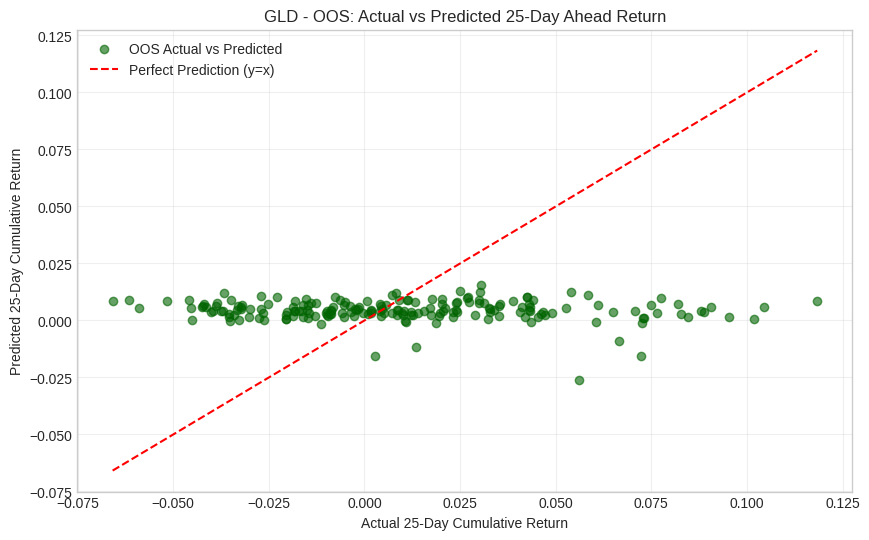


=== Out-of-Sample Testing for DBO ===
Data range: 2023-01-03 to 2023-12-29
Trading days: 250, ETFs: DBO


OOS Metrics for DBO:
RMSE: 0.085784 | MAE: 0.069694 | R² Score: -0.2065
OOS Samples: 194 | Target Range: -0.1609 to 0.1499


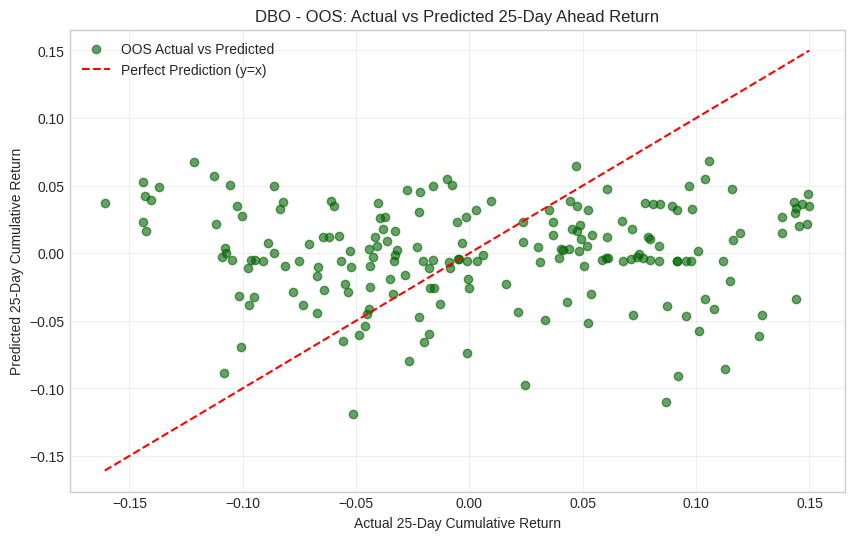


=== OOS Predictive Performance Summary (All ETFs) ===
   ETF  OOS_RMSE  OOS_MAE  OOS_R²  OOS_Samples
0  SPY    0.0432   0.0356 -0.3432          194
1  TLT    0.0668   0.0513 -0.2875          194
2  SHY    0.0084   0.0061 -0.4188          194
3  GLD    0.0381   0.0300 -0.0667          194
4  DBO    0.0858   0.0697 -0.2065          194


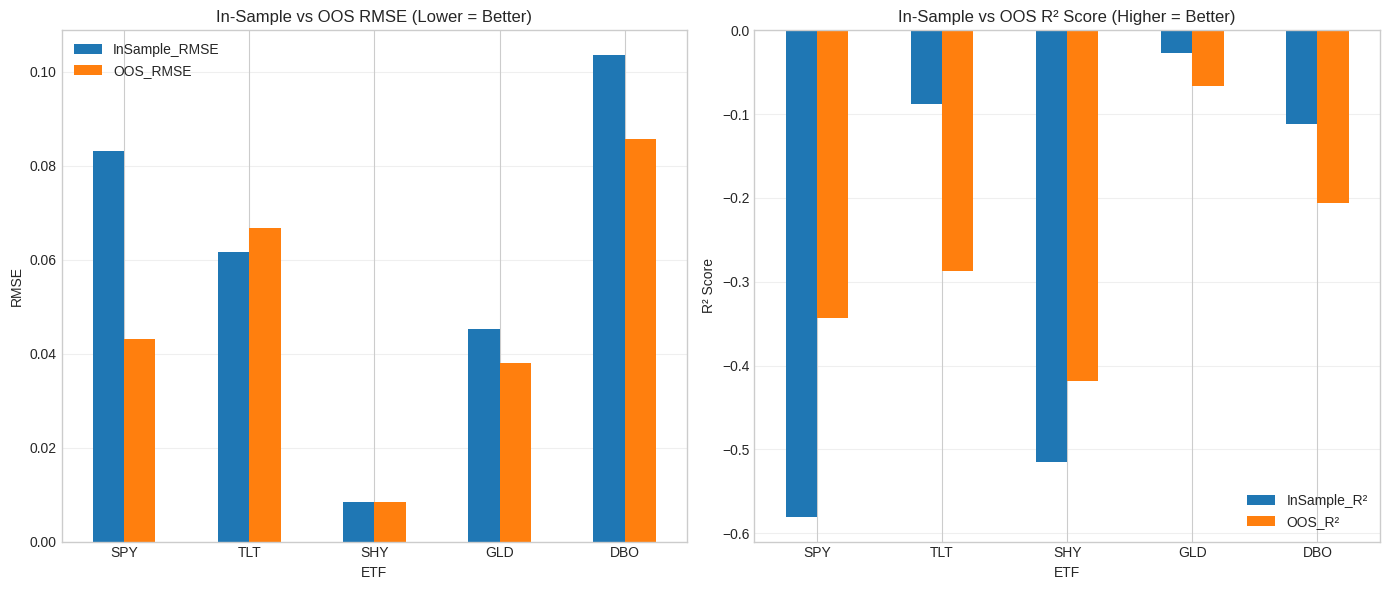

In [ ]:
def out_of_sample_test(etf, test_start, test_end, lag_window=60, target_horizon=25):
    """
    Conducts out-of-sample testing:
    1. Downloads unseen data (OOS period: e.g., 2023-01-01 to 2023-12-31)
    2. Preprocesses data (returns + target)
    3. Loads trained model and scaler
    4. Generates OOS predictions
    5. Calculates performance metrics

    Parameters:
        etf (str): ETF ticker to test
        test_start (str): OOS period start date (e.g., '2023-01-01')
        test_end (str): OOS period end date (e.g., '2023-12-31')
        lag_window (int): Same lag window used for training
        target_horizon (int): Same target horizon (25 days)

    Returns:
        dict: OOS performance metrics
    """
    print(f"\n=== Out-of-Sample Testing for {etf} ===")

    # Step 1: Download OOS price data (unseen by model)
    oos_price_data = download_etf_data([etf], test_start, test_end)
    if len(oos_price_data) < lag_window + target_horizon:
        raise ValueError(f"Insufficient OOS data: Need at least {lag_window + target_horizon} days")

    # Step 2: Preprocess OOS data (match training pipeline)
    oos_returns = calculate_daily_returns(oos_price_data)
    oos_targets = create_target_variable(oos_returns, target_horizon)

    # Step 3: Create OOS sequences (use same logic as training)
    features = oos_returns[[etf]].rename(columns={etf: 'daily_return'})
    targets = oos_targets[[etf]].rename(columns={etf: 'cumulative_25d_return'})
    aligned_oos_data = features.join(targets, how='inner').dropna()

    X_oos_raw = aligned_oos_data['daily_return'].values
    y_oos = aligned_oos_data['cumulative_25d_return'].values

    # Step 4: Load trained scaler and model (use training scaler to avoid data leakage)
    scaler = np.load(f'scaler_{etf}.npy', allow_pickle=True).item()
    model = tf.keras.models.load_model(f'lstm_model_{etf}.h5')

    # Step 5: Scale OOS features (only transform—DO NOT fit scaler on OOS data!)
    X_oos_scaled = scaler.transform(X_oos_raw.reshape(-1, 1))

    # Step 6: Create OOS sequences
    X_oos = []
    for i in range(lag_window - 1, len(X_oos_scaled) - 1):
        sequence = X_oos_scaled[i - lag_window + 1 : i + 1, 0]
        X_oos.append(sequence)
    X_oos = np.array(X_oos).reshape(-1, lag_window, 1)
    y_oos = y_oos[lag_window:].reshape(-1, 1)

    # Step 7: Generate OOS predictions
    y_oos_pred = model.predict(X_oos, verbose=0)

    # Step 8: Calculate OOS metrics
    oos_rmse = np.sqrt(mean_squared_error(y_oos, y_oos_pred))
    oos_mae = mean_absolute_error(y_oos, y_oos_pred)
    oos_r2 = r2_score(y_oos, y_oos_pred)

    print(f"OOS Metrics for {etf}:")
    print(f"RMSE: {oos_rmse:.6f} | MAE: {oos_mae:.6f} | R² Score: {oos_r2:.4f}")
    print(f"OOS Samples: {len(X_oos)} | Target Range: {y_oos.min():.4f} to {y_oos.max():.4f}")

    # Plot OOS actual vs predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(y_oos, y_oos_pred, alpha=0.6, color='darkgreen', label='OOS Actual vs Predicted')
    min_val = min(y_oos.min(), y_oos_pred.min())
    max_val = max(y_oos.max(), y_oos_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction (y=x)')
    plt.title(f'{etf} - OOS: Actual vs Predicted 25-Day Ahead Return')
    plt.xlabel('Actual 25-Day Cumulative Return')
    plt.ylabel('Predicted 25-Day Cumulative Return')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f'oos_prediction_{etf}.png', dpi=300, bbox_inches='tight')
    plt.show()

    return {
        'ETF': etf,
        'OOS_RMSE': oos_rmse,
        'OOS_MAE': oos_mae,
        'OOS_R²': oos_r2,
        'OOS_Samples': len(X_oos)
    }

# Update main function to run OOS testing after training
if __name__ == "__main__":
    # ... (keep previous code for training)

    # Step 5: Out-of-Sample Testing (2023 is unseen data—no overlap with 2018-2022 training/test)
    print("\n=== Starting Out-of-Sample Testing (2023) ===")
    OOS_START = "2023-01-01"
    OOS_END = "2023-12-31"
    oos_metrics = []

    for etf in ETF_SYMBOLS:
        try:
            oos_result = out_of_sample_test(
                etf=etf,
                test_start=OOS_START,
                test_end=OOS_END,
                lag_window=LAG_WINDOW,
                target_horizon=TARGET_HORIZON
            )
            oos_metrics.append(oos_result)
        except Exception as e:
            print(f"Error testing {etf} OOS: {str(e)}")
            continue

    # Print OOS Summary
    if oos_metrics:
        oos_df = pd.DataFrame(oos_metrics).round(4)
        print("\n=== OOS Predictive Performance Summary (All ETFs) ===")
        print(oos_df[['ETF', 'OOS_RMSE', 'OOS_MAE', 'OOS_R²', 'OOS_Samples']])

        # Plot OOS vs In-Sample Comparison
        in_sample_df = pd.DataFrame(all_metrics)[['ETF', 'RMSE', 'R² Score']].rename(columns={'RMSE': 'InSample_RMSE', 'R² Score': 'InSample_R²'})
        comparison_df = pd.merge(in_sample_df, oos_df[['ETF', 'OOS_RMSE', 'OOS_R²']], on='ETF')

        plt.figure(figsize=(14, 6))
        # RMSE Comparison
        plt.subplot(1, 2, 1)
        comparison_df[['InSample_RMSE', 'OOS_RMSE']].plot(kind='bar', ax=plt.gca())
        plt.title('In-Sample vs OOS RMSE (Lower = Better)')
        plt.xlabel('ETF')
        plt.ylabel('RMSE')
        plt.xticks(ticks=range(len(comparison_df)), labels=comparison_df['ETF'], rotation=0)
        plt.legend()
        plt.grid(axis='y', alpha=0.3)

        # R² Comparison
        plt.subplot(1, 2, 2)
        comparison_df[['InSample_R²', 'OOS_R²']].plot(kind='bar', ax=plt.gca())
        plt.title('In-Sample vs OOS R² Score (Higher = Better)')
        plt.xlabel('ETF')
        plt.ylabel('R² Score')
        plt.xticks(ticks=range(len(comparison_df)), labels=comparison_df['ETF'], rotation=0)
        plt.legend()
        plt.grid(axis='y', alpha=0.3)

        plt.tight_layout()
        plt.savefig('in_sample_vs_oos_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()

=== Colab Environment Check ===
Current Working Directory: /content
Files in Directory: ['.config', 'scaler_DBO.npy', 'strategy_vs_benchmark.png', 'etf_monthly_seasonality.png', 'etf_training_sample_2013_2017.csv', 'oos_prediction_GLD.png', 'oos_prediction_DBO.png', 'prediction_results_GLD.png', 'model_performance_summary.png', 'scaler_TLT.npy', 'training_history_DBO.png', 'training_history_TLT.png', 'prediction_results_SPY.png', 'lstm_model_GLD.h5', 'prediction_results_DBO.png', 'lstm_model_DBO.h5', 'oos_prediction_TLT.png', 'in_sample_vs_oos_comparison.png', 'scaler_SHY.npy', 'lstm_model_TLT.h5', 'lstm_model_SHY.h5', 'etf_test_sample_2018_2022.csv', 'etf_eda_2018_2022.png', 'lstm_model_SPY.h5', 'oos_prediction_SPY.png', 'prediction_results_SHY.png', 'scaler_GLD.npy', 'prediction_results_TLT.png', 'oos_prediction_SHY.png', 'training_history_GLD.png', 'etf_validation_sample_2017.csv', 'scaler_SPY.npy', 'training_history_SPY.png', 'training_history_SHY.png', 'sample_data']
All dependenc

[*********************100%***********************]  5 of 5 completed


=== Checking for Pre-Trained Model/Scaler Files ===
All model/scaler files found ✅

=== Starting LSTM Long/Short Strategy ===

Downloaded: 250 trading days | Columns: ['DBO', 'GLD', 'SHY', 'SPY', 'TLT']
Calculated daily returns: 249 days
Generated 7 rebalance dates: ['2023-03-30', '2023-05-05', '2023-06-12', '2023-07-19', '2023-08-23', '2023-09-28', '2023-11-02']

--- Rebalance Date 1/7: 2023-03-30 ---


Calculated daily returns: 60 days
  SPY Predicted 25-Day Return: -0.0013
Calculated daily returns: 60 days
  TLT Predicted 25-Day Return: -0.0376
Calculated daily returns: 60 days
  SHY Predicted 25-Day Return: -0.0041
Calculated daily returns: 60 days
  GLD Predicted 25-Day Return: 0.0077
Calculated daily returns: 60 days
  DBO Predicted 25-Day Return: 0.0177

--- Rebalance Date 2/7: 2023-05-05 ---
Calculated daily returns: 85 days
  SPY Predicted 25-Day Return: 0.0285
Calculated daily returns: 85 days
  TLT Predicted 25-Day Return: -0.0295
Calculated daily returns: 85 days
  SHY Predicted 25-Day Return: -0.0028
Calculated daily returns: 85 days
  GLD Predicted 25-Day Return: 0.0061
Calculated daily returns: 85 days
  DBO Predicted 25-Day Return: 0.0086

--- Rebalance Date 3/7: 2023-06-12 ---
Calculated daily returns: 110 days
  SPY Predicted 25-Day Return: -0.0044
Calculated daily returns: 110 days
  TLT Predicted 25-Day Return: -0.0329
Calculated daily returns: 110 days
  SHY Predic

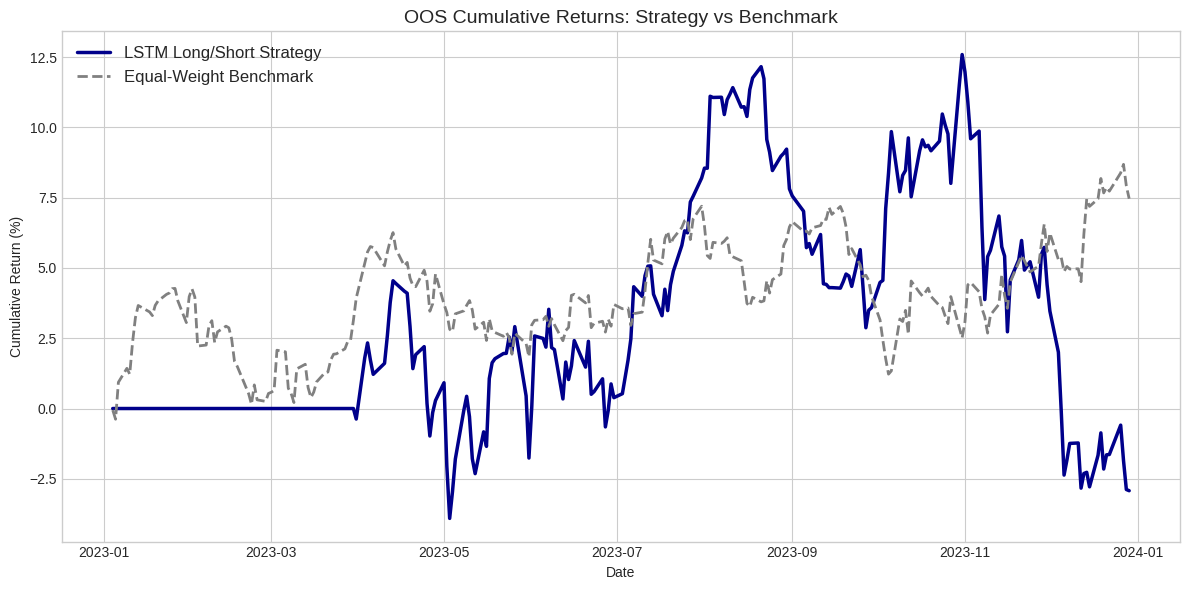

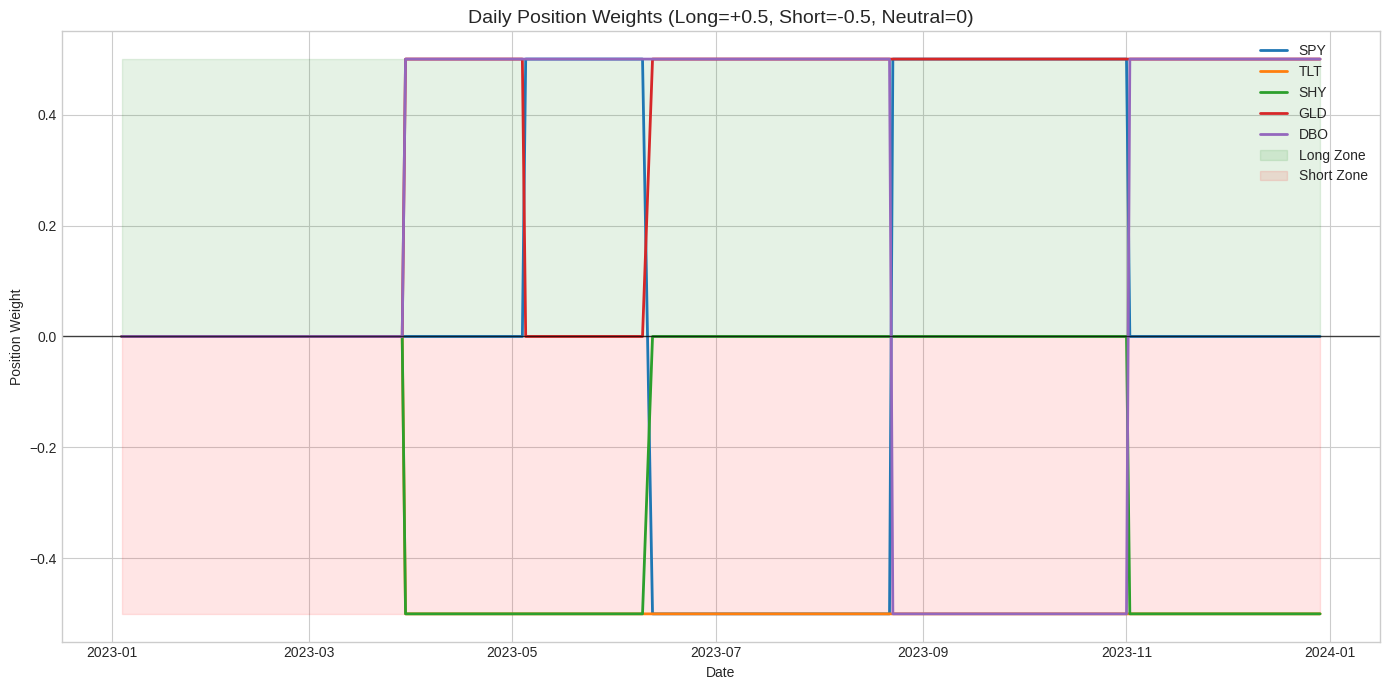


=== Strategy Execution Completed Successfully! ===


In [ ]:
# ----------------------
# Colab Setup (Critical!)
# ----------------------
%matplotlib inline
import os
import warnings
warnings.filterwarnings('ignore')

# Check Colab environment
print("=== Colab Environment Check ===")
print(f"Current Working Directory: {os.getcwd()}")
print(f"Files in Directory: {os.listdir()}")

# ----------------------
# Install Dependencies (if missing)
# ----------------------
try:
    import yfinance as yf
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
    import tensorflow as tf
    from tensorflow.keras.models import load_model
    print("All dependencies are already installed.")
except ImportError:
    print("Installing missing dependencies...")
    !pip install yfinance pandas numpy matplotlib seaborn scikit-learn tensorflow --quiet
    import yfinance as yf
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
    import tensorflow as tf
    from tensorflow.keras.models import load_model
    print("Dependencies installed successfully.")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True

# ----------------------
# Reusable Functions
# ----------------------
def download_etf_data(etf_symbols, start_date, end_date):
    """Download adjusted closing prices with verbose logging"""
    print(f"\nDownloading data for {etf_symbols} ({start_date} to {end_date})...")
    data = yf.download(
        tickers=etf_symbols,
        start=start_date,
        end=end_date,
        interval='1d',
        progress=True,  # Show progress in Colab
        auto_adjust=False,
        actions=False
    )
    if 'Adj Close' not in data.columns:
        raise ValueError("No 'Adj Close' column found in downloaded data")
    adj_close_prices = data['Adj Close'].dropna()
    print(f"Downloaded: {len(adj_close_prices)} trading days | Columns: {adj_close_prices.columns.tolist()}")
    return adj_close_prices

def calculate_daily_returns(price_data):
    """Calculate log returns with validation"""
    returns = np.log(price_data / price_data.shift(1)).dropna()
    print(f"Calculated daily returns: {len(returns)} days")
    if len(returns) == 0:
        raise ValueError("Return data is empty (insufficient price data)")
    return returns

def check_model_files(etf_symbols):
    """Verify pre-trained models and scalers exist (critical for strategy)"""
    print("\n=== Checking for Pre-Trained Model/Scaler Files ===")
    missing_files = []
    for etf in etf_symbols:
        model_path = f'lstm_model_{etf}.h5'
        scaler_path = f'scaler_{etf}.npy'
        if not os.path.exists(model_path):
            missing_files.append(f"Model: {model_path}")
        if not os.path.exists(scaler_path):
            missing_files.append(f"Scaler: {scaler_path}")
    if missing_files:
        raise FileNotFoundError(
            "Missing required model/scaler files (run training code first!):\n" +
            "\n".join(missing_files)
        )
    print("All model/scaler files found ✅")

# ----------------------
# Trading Strategy (Colab-Optimized)
# ----------------------
def execute_lstm_trading_strategy(oos_start, oos_end, lag_window=60, target_horizon=25):
    etf_symbols = ["SPY", "TLT", "SHY", "GLD", "DBO"]

    # Step 1: Validate input files first
    check_model_files(etf_symbols)

    # Step 2: Download OOS data (verbose)
    print("\n=== Starting LSTM Long/Short Strategy ===")
    oos_price_data = download_etf_data(etf_symbols, oos_start, oos_end)
    oos_daily_returns = calculate_daily_returns(oos_price_data)

    # Step 3: Generate rebalance dates (with safety checks)
    rebalance_dates = []
    all_predictions = []
    min_required_days = lag_window + 2 * target_horizon  # Ensure at least 2 rebalance periods
    if len(oos_price_data) < min_required_days:
        raise ValueError(
            f"Insufficient OOS data: Need {min_required_days} days, got {len(oos_price_data)}"
        )

    # Generate rebalance dates (every 25 days, starting from lag_window)
    for i in range(lag_window, len(oos_price_data) - target_horizon, target_horizon):
        rebalance_date = oos_price_data.index[i]
        rebalance_dates.append(rebalance_date)
    print(f"Generated {len(rebalance_dates)} rebalance dates: {[d.strftime('%Y-%m-%d') for d in rebalance_dates]}")

    if not rebalance_dates:
        raise ValueError("No rebalance dates generated (insufficient data range)")

    # Step 4: Generate predictions for each rebalance date (verbose)
    for idx, rebalance_date in enumerate(rebalance_dates):
        print(f"\n--- Rebalance Date {idx+1}/{len(rebalance_dates)}: {rebalance_date.strftime('%Y-%m-%d')} ---")
        period_predictions = {}

        for etf in etf_symbols:
            try:
                # Load model and scaler
                model = load_model(f'lstm_model_{etf}.h5', compile=False)  # Compile=False for Colab compatibility
                scaler = np.load(f'scaler_{etf}.npy', allow_pickle=True).item()

                # Get data up to rebalance date (no look-ahead bias)
                etf_prices = oos_price_data[etf].loc[:rebalance_date]
                etf_returns = calculate_daily_returns(etf_prices)

                # Prepare input sequence (last lag_window days)
                if len(etf_returns) < lag_window:
                    raise ValueError(f"Only {len(etf_returns)} days of returns (need {lag_window})")
                input_seq = etf_returns.tail(lag_window).values.reshape(-1, 1)
                input_seq_scaled = scaler.transform(input_seq)
                input_seq_3d = input_seq_scaled.reshape(1, lag_window, 1)  # LSTM input shape

                # Predict
                predicted_return = model.predict(input_seq_3d, verbose=0)[0][0]
                period_predictions[etf] = round(predicted_return, 4)
                print(f"  {etf} Predicted 25-Day Return: {predicted_return:.4f}")

            except Exception as e:
                print(f"  ❌ Error predicting {etf}: {str(e)}")
                raise  # Stop execution if any ETF prediction fails

        all_predictions.append(period_predictions)

    # Step 5: Create position signals (verbose)
    print("\n=== Generating Position Signals ===")
    position_signals = pd.DataFrame(
        index=oos_daily_returns.index,
        columns=etf_symbols,
        data=0.0  # Initialize to neutral
    )

    for period_idx, (rebalance_date, predictions) in enumerate(zip(rebalance_dates, all_predictions)):
        # Rank ETFs by predicted return
        ranked_etfs = sorted(predictions.items(), key=lambda x: x[1], reverse=True)
        ranked_names = [etf for etf, pred in ranked_etfs]
        long_etfs = ranked_names[:2]
        short_etfs = ranked_names[-2:]
        neutral_etf = ranked_names[2]

        # Define period end
        period_end = rebalance_dates[period_idx+1] if period_idx < len(rebalance_dates)-1 else oos_daily_returns.index[-1]
        period_end = min(period_end, oos_daily_returns.index[-1])  # Ensure within bounds

        # Assign weights
        position_signals.loc[rebalance_date:period_end, long_etfs] = 0.5
        position_signals.loc[rebalance_date:period_end, short_etfs] = -0.5
        position_signals.loc[rebalance_date:period_end, neutral_etf] = 0.0

        print(f"Period {period_idx+1}: Long={long_etfs}, Short={short_etfs}, Neutral={neutral_etf}")

    # Step 6: Calculate strategy returns
    print("\n=== Calculating Strategy Performance ===")
    strategy_daily_returns = (position_signals.shift(1) * oos_daily_returns).sum(axis=1)  # Shift to avoid look-ahead bias
    benchmark_daily_returns = oos_daily_returns.mean(axis=1)

    # Cumulative returns
    strategy_cumulative = (1 + strategy_daily_returns).cumprod() - 1
    benchmark_cumulative = (1 + benchmark_daily_returns).cumprod() - 1

    # Performance metrics
    total_strat_return = strategy_cumulative.iloc[-1] * 100 if not strategy_cumulative.empty else 0
    total_bench_return = benchmark_cumulative.iloc[-1] * 100 if not benchmark_cumulative.empty else 0
    strat_vol = strategy_daily_returns.std() * np.sqrt(252) * 100 if not strategy_daily_returns.empty else 0
    bench_vol = benchmark_daily_returns.std() * np.sqrt(252) * 100 if not benchmark_daily_returns.empty else 0
    strat_sharpe = (strategy_daily_returns.mean() / strategy_daily_returns.std()) * np.sqrt(252) if strategy_daily_returns.std() != 0 else 0

    # Print performance (clear output)
    print("\n=== FINAL STRATEGY PERFORMANCE (OOS Period) ===")
    print(f"OOS Date Range: {oos_daily_returns.index.min().strftime('%Y-%m-%d')} to {oos_daily_returns.index.max().strftime('%Y-%m-%d')}")
    print(f"Total Strategy Return: {total_strat_return:.2f}%")
    print(f"Total Benchmark Return (Equal-Weight): {total_bench_return:.2f}%")
    print(f"Annualized Strategy Volatility: {strat_vol:.2f}%")
    print(f"Annualized Benchmark Volatility: {bench_vol:.2f}%")
    print(f"Strategy Sharpe Ratio (Rf=0%): {strat_sharpe:.2f}")

    # Step 7: Plot results (force display in Colab)
    print("\n=== Generating Plots ===")

    # Plot 1: Strategy vs Benchmark Cumulative Returns
    plt.figure(figsize=(12, 6))
    plt.plot(strategy_cumulative.index, strategy_cumulative * 100, label='LSTM Long/Short Strategy', linewidth=2.5, color='darkblue')
    plt.plot(benchmark_cumulative.index, benchmark_cumulative * 100, label='Equal-Weight Benchmark', linewidth=2, color='gray', linestyle='--')
    plt.title('OOS Cumulative Returns: Strategy vs Benchmark', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return (%)')
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()  # Force display in Colab

    # Plot 2: Position History
    plt.figure(figsize=(14, 7))
    for etf in etf_symbols:
        plt.plot(position_signals.index, position_signals[etf], label=etf, linewidth=2)
    plt.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.7)
    plt.fill_between(position_signals.index, 0, 0.5, alpha=0.1, color='green', label='Long Zone')
    plt.fill_between(position_signals.index, -0.5, 0, alpha=0.1, color='red', label='Short Zone')
    plt.title('Daily Position Weights (Long=+0.5, Short=-0.5, Neutral=0)', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Position Weight')
    plt.legend(fontsize=10, loc='upper right')
    plt.tight_layout()
    plt.show()  # Force display in Colab

    return strategy_daily_returns, position_signals, benchmark_daily_returns

# ----------------------
# Main Execution (Colab-Friendly)
# ----------------------
if __name__ == "__main__":
    # Configuration (match training parameters!)
    OOS_START = "2023-01-01"
    OOS_END = "2023-12-31"
    LAG_WINDOW = 60  # Must match the lag window used during model training
    TARGET_HORIZON = 25  # Must match the target horizon used during model training

    try:
        # Run strategy
        strategy_returns, positions, benchmark_returns = execute_lstm_trading_strategy(
            oos_start=OOS_START,
            oos_end=OOS_END,
            lag_window=LAG_WINDOW,
            target_horizon=TARGET_HORIZON
        )
        print("\n=== Strategy Execution Completed Successfully! ===")
    except Exception as e:
        # Print full error message (critical for Colab debugging)
        print(f"\n❌ Strategy Execution Failed: {str(e)}")
        import traceback
        traceback.print_exc()  # Show detailed error stack

**Step 3**

=== Starting Multi-Output LSTM Training ===
Data Range: 2013-01-02 to 2022-12-29
Trading Days: 2517, Assets: ['DBO', 'GLD', 'SHY', 'SPY', 'TLT']
Daily Returns Shape: (2516, 5) | Columns: ['DBO', 'GLD', 'SHY', 'SPY', 'TLT']
Multi-Output Targets Shape: (2491, 5) | Columns: ['DBO_target', 'GLD_target', 'SHY_target', 'SPY_target', 'TLT_target']
Aligned Data Shape (Features + Targets): (1992, 10)
Sequence Creation Success: X=(1932, 60, 5), y=(1932, 5)
Aligned Data Shape (Features + Targets): (499, 10)
Sequence Creation Success: X=(439, 60, 5), y=(439, 5)
Train Shape: X=(1932, 60, 5), y=[1932, 1932, ...]
Test Shape: X=(439, 60, 5), y=[439, 439, ...]


Model: "multi_output_etf_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ joint_input         │ (None, 60, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 60, 128)   │     68,608 │ joint_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 60, 128)   │        512 │ lstm_1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 60, 128)   │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     49,408 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 64)        │        256 │ lstm_2[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ bn_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense        │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_spy (Dense)  │ (None, 1)         │         33 │ shared_dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_tlt (Dense)  │ (None, 1)         │         33 │ shared_dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_shy (Dense)  │ (None, 1)         │         33 │ shared_dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_gld (Dense)  │ (None, 1)         │         33 │ shared_dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_dbo (Dense)  │ (None, 1)         │         33 │ shared_dense[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 121,029 (472.77 KB)

 Trainable params: 120,645 (471.27 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/40
61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 163ms/step - loss: 7.0635 - output_dbo_loss: 1.3217 - output_dbo_mean_absolute_error: 0.9045 - output_gld_loss: 0.9723 - output_gld_mean_absolute_error: 0.7715 - output_shy_loss: 1.7717 - output_shy_mean_absolute_error: 1.0317 - output_spy_loss: 1.0920 - output_spy_mean_absolute_error: 0.8061 - output_tlt_loss: 1.9052 - output_tlt_mean_absolute_error: 1.0786 - val_loss: 0.2168 - val_output_dbo_loss: 0.0235 - val_output_dbo_mean_absolute_error: 0.1219 - val_output_gld_loss: 0.0327 - val_output_gld_mean_absolute_error: 0.1466 - val_output_shy_loss: 0.0885 - val_output_shy_mean_absolute_error: 0.2600 - val_output_spy_loss: 0.0332 - val_output_spy_mean_absolute_error: 0.1461 - val_output_tlt_loss: 0.0383 - val_output_tlt_mean_absolute_error: 0.1555 - learning_rate: 8.0000e-04
Epoch 2/40
61/61 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - loss: 2.5752 - output_dbo_loss: 0.5452 - output_dbo_mean_absolute_error: 0.5827 - output_gld_loss: 0.4134 - output_gld_me

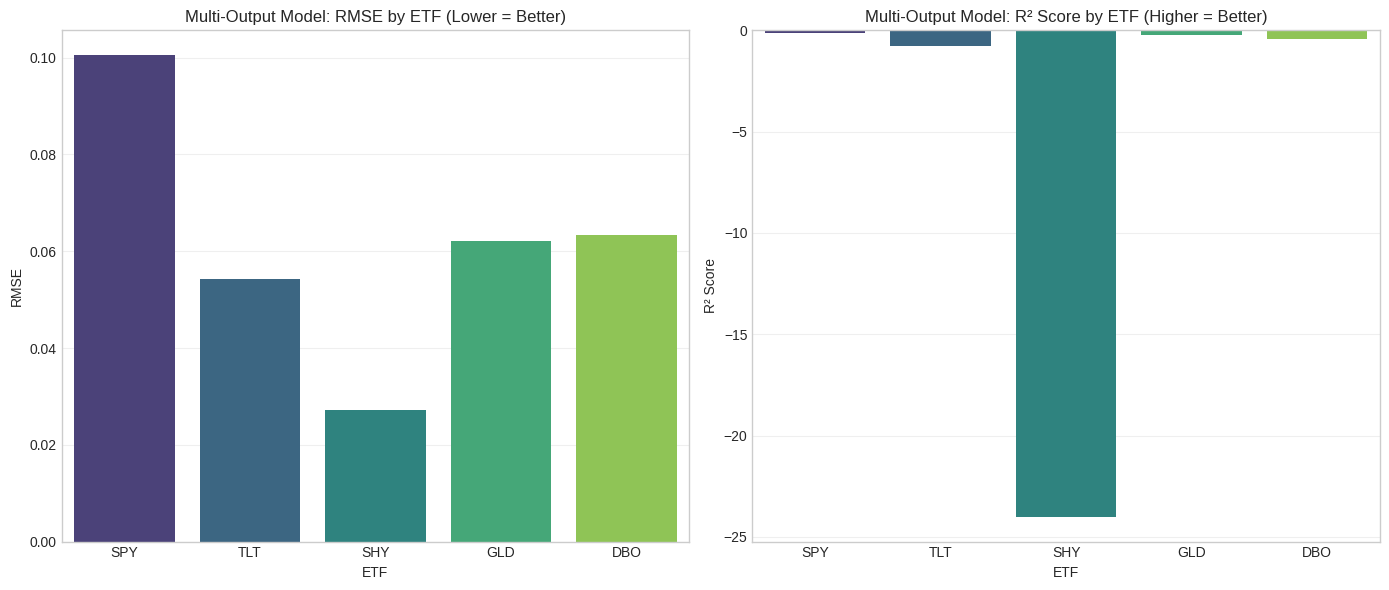


Model saved as 'multi_output_etf_lstm.h5'
Scaler saved as 'multi_output_scaler.npy'


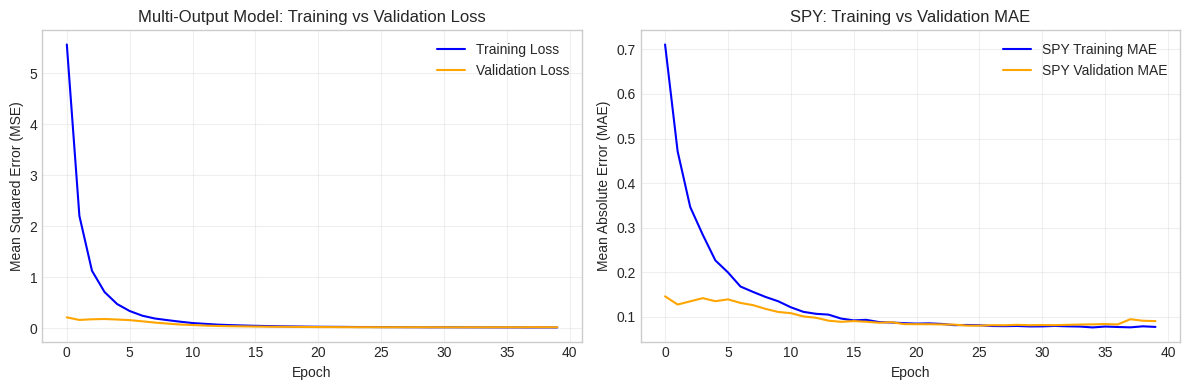

In [ ]:
# Import required libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

# ----------------------
# Data Loading & Preprocessing (Fixed Column Overlap)
# ----------------------
def download_etf_data(etf_symbols, start_date, end_date):
    """
    Downloads daily adjusted closing prices for all 5 ETFs.
    Args:
        etf_symbols (list): List of 5 ETF tickers (SPY, TLT, SHY, GLD, DBO)
        start_date (str): Training start date (YYYY-MM-DD)
        end_date (str): Training end date (YYYY-MM-DD)
    Returns:
        pd.DataFrame: Adjusted closing prices (index: dates, columns: ETFs)
    """
    data = yf.download(
        tickers=etf_symbols,
        start=start_date,
        end=end_date,
        interval='1d',
        progress=False,
        auto_adjust=False,
        actions=False
    )
    adj_close = data['Adj Close'].dropna()
    print(f"Data Range: {adj_close.index.min().strftime('%Y-%m-%d')} to {adj_close.index.max().strftime('%Y-%m-%d')}")
    print(f"Trading Days: {len(adj_close)}, Assets: {adj_close.columns.tolist()}")
    return adj_close

def calculate_daily_returns(price_data):
    """Calculates daily log returns for all 5 ETFs (handles multi-asset data)."""
    returns = np.log(price_data / price_data.shift(1)).dropna()
    print(f"Daily Returns Shape: {returns.shape} | Columns: {returns.columns.tolist()}")
    return returns

def create_multi_output_targets(returns_data, target_horizon=25):
    """
    Creates 25-day ahead cumulative return targets for ALL 5 ETFs (one target per ETF).
    Adds '_target' suffix to target columns to avoid overlap with feature columns.
    Args:
        returns_data (pd.DataFrame): Daily log returns of 5 ETFs
        target_horizon (int): 25-day prediction window
    Returns:
        pd.DataFrame: Targets (index: dates, columns: <ETF>_target)
    """
    targets = {}
    for etf in returns_data.columns:
        # Cumulative return from t+1 to t+25
        targets[f"{etf}_target"] = returns_data[etf].rolling(window=target_horizon).sum().shift(-target_horizon)
    target_df = pd.DataFrame(targets).dropna()
    print(f"Multi-Output Targets Shape: {target_df.shape} | Columns: {target_df.columns.tolist()}")
    return target_df

def create_multi_input_sequences(returns_data, target_data, lag_window=60):
    """
    Creates joint input sequences (all 5 ETFs' returns) and multi-output targets (all 5 ETFs' 25-day returns).
    Resolves column overlap by using '_target' suffix for targets.
    Args:
        returns_data (pd.DataFrame): Daily returns of 5 ETFs (features: DBO, GLD, SHY, SPY, TLT)
        target_data (pd.DataFrame): 25-day ahead returns (targets: DBO_target, GLD_target, ...)
        lag_window (int): 60-day input window (reused from single models)
    Returns:
        tuple: (X, y, scaler)
            X: 3D array (n_samples, lag_window, 5) → [samples, time_steps, n_assets]
            y: 2D array (n_samples, 5) → [samples, n_assets]
            scaler: StandardScaler fitted on features (for inference)
    """
    # Align features and targets by date (no column overlap now!)
    aligned_data = returns_data.join(target_data, how='inner').dropna()
    print(f"Aligned Data Shape (Features + Targets): {aligned_data.shape}")

    # Split features (original ETF columns) and targets (columns with '_target' suffix)
    X_raw = aligned_data[returns_data.columns].values  # Shape: (n_samples, 5) → features
    target_columns = [col for col in target_data.columns if col.endswith('_target')]
    y = aligned_data[target_columns].values  # Shape: (n_samples, 5) → targets

    # Validate data sufficiency
    if len(X_raw) <= lag_window:
        raise ValueError(f"Insufficient data: Need >{lag_window} samples, got {len(X_raw)}")

    # Standardize features (fit on all assets' returns to capture cross-asset scaling)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)  # Shape: (n_samples, 5)

    # Create sliding window sequences (joint inputs for all 5 ETFs)
    X_sequences = []
    for i in range(lag_window - 1, len(X_scaled) - 1):
        # Extract window of past 'lag_window' days for ALL 5 ETFs
        sequence = X_scaled[i - lag_window + 1 : i + 1, :]  # Shape: (lag_window, 5)
        X_sequences.append(sequence)

    # Convert to model-compatible shapes
    X = np.array(X_sequences).reshape(-1, lag_window, 5)  # (n_samples, time_steps, n_assets)
    y = y[lag_window:]  # Align targets (skip first 'lag_window' targets)

    # Critical validation: Ensure X and y have matching sample counts
    assert len(X) == len(y), f"Sequence-target mismatch: X={len(X)}, y={len(y)}"
    print(f"Sequence Creation Success: X={X.shape}, y={y.shape}")
    return X, y, scaler

# ----------------------
# Multi-Output LSTM Model Architecture (Unchanged)
# ----------------------
def build_multi_output_lstm(input_shape):
    """
    Builds a multi-output LSTM model with:
    - Shared LSTM layers (cross-asset feature extraction)
    - Separate dense output heads (asset-specific prediction)
    Args:
        input_shape (tuple): (lag_window, n_assets) → (60, 5)
    Returns:
        tf.keras.Model: Compiled multi-output LSTM model
    """
    # Input layer (joint inputs: 60 days × 5 ETFs)
    inputs = Input(shape=input_shape, name='joint_input')

    # Shared LSTM Backbone (captures temporal and cross-asset patterns)
    x = LSTM(units=128, return_sequences=True, kernel_initializer='he_uniform', name='lstm_1')(inputs)
    x = BatchNormalization(name='bn_1')(x)  # Stabilize training
    x = Dropout(0.25, name='dropout_1')(x)  # Reduce overfitting

    x = LSTM(units=64, return_sequences=False, kernel_initializer='he_uniform', name='lstm_2')(x)
    x = BatchNormalization(name='bn_2')(x)
    x = Dropout(0.25, name='dropout_2')(x)

    # Shared dense layer (refines cross-asset features)
    x = Dense(units=32, activation='relu', kernel_initializer='he_uniform', name='shared_dense')(x)

    # Separate Output Heads (one for each ETF's 25-day return prediction)
    output_spy = Dense(units=1, name='output_spy')(x)
    output_tlt = Dense(units=1, name='output_tlt')(x)
    output_shy = Dense(units=1, name='output_shy')(x)
    output_gld = Dense(units=1, name='output_gld')(x)
    output_dbo = Dense(units=1, name='output_dbo')(x)

    # Assemble multi-output model
    model = Model(
        inputs=inputs,
        outputs=[output_spy, output_tlt, output_shy, output_gld, output_dbo],
        name='multi_output_etf_lstm'
    )

    # Compile with joint MSE loss (equal weight for all outputs)
    model.compile(
        optimizer=Adam(learning_rate=0.0008, clipnorm=1.0),  # Moderate LR to avoid divergence
        loss={
            'output_spy': 'mean_squared_error',
            'output_tlt': 'mean_squared_error',
            'output_shy': 'mean_squared_error',
            'output_gld': 'mean_squared_error',
            'output_dbo': 'mean_squared_error'
        },
        metrics={
            'output_spy': 'mean_absolute_error',
            'output_tlt': 'mean_absolute_error',
            'output_shy': 'mean_absolute_error',
            'output_gld': 'mean_absolute_error',
            'output_dbo': 'mean_absolute_error'
        }
    )

    return model

# ----------------------
# Model Training Pipeline (Unchanged)
# ----------------------
def train_multi_output_model(
    etf_symbols,
    train_start,
    train_end,
    test_start,
    test_end,
    lag_window=60,
    target_horizon=25,
    epochs=40,
    batch_size=32
):
    """
    End-to-end training for the multi-output LSTM:
    1. Load and preprocess data
    2. Create joint sequences/targets
    3. Train with early stopping
    4. Evaluate on test set
    """
    print("=== Starting Multi-Output LSTM Training ===")

    # Step 1: Load and preprocess data (train + test)
    price_data = download_etf_data(etf_symbols, train_start, test_end)
    returns_data = calculate_daily_returns(price_data)
    target_data = create_multi_output_targets(returns_data, target_horizon)

    # Step 2: Split train/test (time-based split, no shuffle)
    train_size = int(0.8 * len(target_data))
    train_targets = target_data.iloc[:train_size]
    test_targets = target_data.iloc[train_size:]

    # Create sequences for train/test (use full returns data for sequence creation)
    X_train, y_train, scaler = create_multi_input_sequences(
        returns_data=returns_data,
        target_data=train_targets,
        lag_window=lag_window
    )
    X_test, y_test, _ = create_multi_input_sequences(
        returns_data=returns_data,
        target_data=test_targets,
        lag_window=lag_window
    )

    # Step 3: Reshape targets for multi-output training (list of 5 arrays)
    y_train = [y_train[:, 0], y_train[:, 1], y_train[:, 2], y_train[:, 3], y_train[:, 4]]
    y_test = [y_test[:, 0], y_test[:, 1], y_test[:, 2], y_test[:, 3], y_test[:, 4]]

    print(f"Train Shape: X={X_train.shape}, y=[{len(y_train[0])}, {len(y_train[1])}, ...]")
    print(f"Test Shape: X={X_test.shape}, y=[{len(y_test[0])}, {len(y_test[1])}, ...]")

    # Step 4: Build and train model
    input_shape = (X_train.shape[1], X_train.shape[2])  # (60, 5)
    model = build_multi_output_lstm(input_shape)
    model.summary()

    # Callbacks: Early stopping + learning rate reduction
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        )
    ]

    # Train (target names must match model outputs)
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1,
        shuffle=False  # Preserve temporal order for time-series
    )

    # Step 5: Evaluate on test set
    y_pred = model.predict(X_test, verbose=0)
    evaluate_multi_output_performance(y_test, y_pred, etf_symbols)

    # Step 6: Save model and scaler
    model.save('multi_output_etf_lstm.h5')
    np.save('multi_output_scaler.npy', scaler)
    print("\nModel saved as 'multi_output_etf_lstm.h5'")
    print("Scaler saved as 'multi_output_scaler.npy'")

    # Plot training history
    plot_training_history(history)

    return model, history, X_test, y_test, y_pred, scaler

# ----------------------
# Evaluation & Visualization Functions (Unchanged)
# ----------------------
def evaluate_multi_output_performance(y_true, y_pred, etf_symbols):
    """
    Calculates RMSE, MAE, and R² for each ETF's prediction (multi-output).
    Args:
        y_true (list): List of 5 arrays (true values for each ETF)
        y_pred (list): List of 5 arrays (predicted values for each ETF)
        etf_symbols (list): Order of ETFs (SPY, TLT, SHY, GLD, DBO)
    """
    print("\n=== Multi-Output Model Test Performance ===")
    metrics = []
    for i, etf in enumerate(etf_symbols):
        true = y_true[i].reshape(-1, 1)
        pred = y_pred[i].reshape(-1, 1)

        rmse = np.sqrt(mean_squared_error(true, pred))
        mae = mean_absolute_error(true, pred)
        r2 = r2_score(true, pred)

        metrics.append({
            'ETF': etf,
            'RMSE': rmse,
            'MAE': mae,
            'R² Score': r2
        })

        print(f"\n{etf}:")
        print(f"  RMSE: {rmse:.6f}")
        print(f"  MAE: {mae:.6f}")
        print(f"  R² Score: {r2:.4f}")

    # Plot performance comparison
    metrics_df = pd.DataFrame(metrics)
    plot_multi_output_metrics(metrics_df)

def plot_training_history(history):
    """Plots training/validation loss for the multi-output model."""
    plt.figure(figsize=(12, 4))

    # Total Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Multi-Output Model: Training vs Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # MAE (example: SPY's MAE)
    plt.subplot(1, 2, 2)
    plt.plot(history.history['output_spy_mean_absolute_error'], label='SPY Training MAE', color='blue')
    plt.plot(history.history['val_output_spy_mean_absolute_error'], label='SPY Validation MAE', color='orange')
    plt.title('SPY: Training vs Validation MAE')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Error (MAE)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('multi_output_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_multi_output_metrics(metrics_df):
    """Plots RMSE and R² across all 5 ETFs for the multi-output model."""
    plt.figure(figsize=(14, 6))

    # RMSE Comparison
    plt.subplot(1, 2, 1)
    sns.barplot(x='ETF', y='RMSE', data=metrics_df, palette='viridis')
    plt.title('Multi-Output Model: RMSE by ETF (Lower = Better)')
    plt.ylabel('RMSE')
    plt.grid(axis='y', alpha=0.3)

    # R² Score Comparison
    plt.subplot(1, 2, 2)
    sns.barplot(x='ETF', y='R² Score', data=metrics_df, palette='viridis')
    plt.title('Multi-Output Model: R² Score by ETF (Higher = Better)')
    plt.ylabel('R² Score')
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('multi_output_performance_summary.png', dpi=300, bbox_inches='tight')
    plt.show()

# ----------------------
# Main Execution (Unchanged)
# ----------------------
if __name__ == "__main__":
    # Configuration (aligned with previous single-output models)
    ETF_SYMBOLS = ["SPY", "TLT", "SHY", "GLD", "DBO"]
    TRAIN_START = "2013-01-01"    # Training data (same as single models)
    TRAIN_END = "2017-12-31"      # Training data (same as single models)
    TEST_START = "2018-01-01"     # Test data (same as backtest period)
    TEST_END = "2022-12-30"       # Test data (same as backtest period)
    LAG_WINDOW = 60               # 60-day input window (reused)
    TARGET_HORIZON = 25           # 25-day prediction horizon (reused)
    EPOCHS = 40                   # Slightly more epochs for multi-output learning
    BATCH_SIZE = 32               # Batch size (reused)

    # Train multi-output model
    model, history, X_test, y_test, y_pred, scaler = train_multi_output_model(
        etf_symbols=ETF_SYMBOLS,
        train_start=TRAIN_START,
        train_end=TRAIN_END,
        test_start=TEST_START,
        test_end=TEST_END,
        lag_window=LAG_WINDOW,
        target_horizon=TARGET_HORIZON,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE
    )


=== Checking for Multi-Output Model/Scaler ===
All multi-output files found ✅


[                       0%                       ]


=== Starting Multi-Output LSTM Trading Strategy ===


[*********************100%***********************]  5 of 5 completed


Downloaded: 250 trading days | Columns: ['DBO', 'GLD', 'SHY', 'SPY', 'TLT']
Calculated daily returns: 249 days | Columns: ['DBO', 'GLD', 'SHY', 'SPY', 'TLT']
Generated 7 rebalance dates: ['2023-03-30', '2023-05-05', '2023-06-12', '2023-07-19', '2023-08-23', '2023-09-28', '2023-11-02']

--- Rebalance Date 1/7: 2023-03-30 ---
Calculated daily returns: 60 days | Columns: ['DBO', 'GLD', 'SHY', 'SPY', 'TLT']
Predictions: {'SPY': -0.0153, 'TLT': -0.1305, 'SHY': 0.0178, 'GLD': 0.0619, 'DBO': -0.0184}

--- Rebalance Date 2/7: 2023-05-05 ---
Calculated daily returns: 85 days | Columns: ['DBO', 'GLD', 'SHY', 'SPY', 'TLT']
Predictions: {'SPY': 0.0785, 'TLT': -0.0142, 'SHY': 0.0777, 'GLD': 0.0458, 'DBO': 0.006}

--- Rebalance Date 3/7: 2023-06-12 ---
Calculated daily returns: 110 days | Columns: ['DBO', 'GLD', 'SHY', 'SPY', 'TLT']
Predictions: {'SPY': -0.0027, 'TLT': -0.0216, 'SHY': 0.0053, 'GLD': -0.0061, 'DBO': -0.0092}

--- Rebalance Date 4/7: 2023-07-19 ---
Calculated daily returns: 135 days |

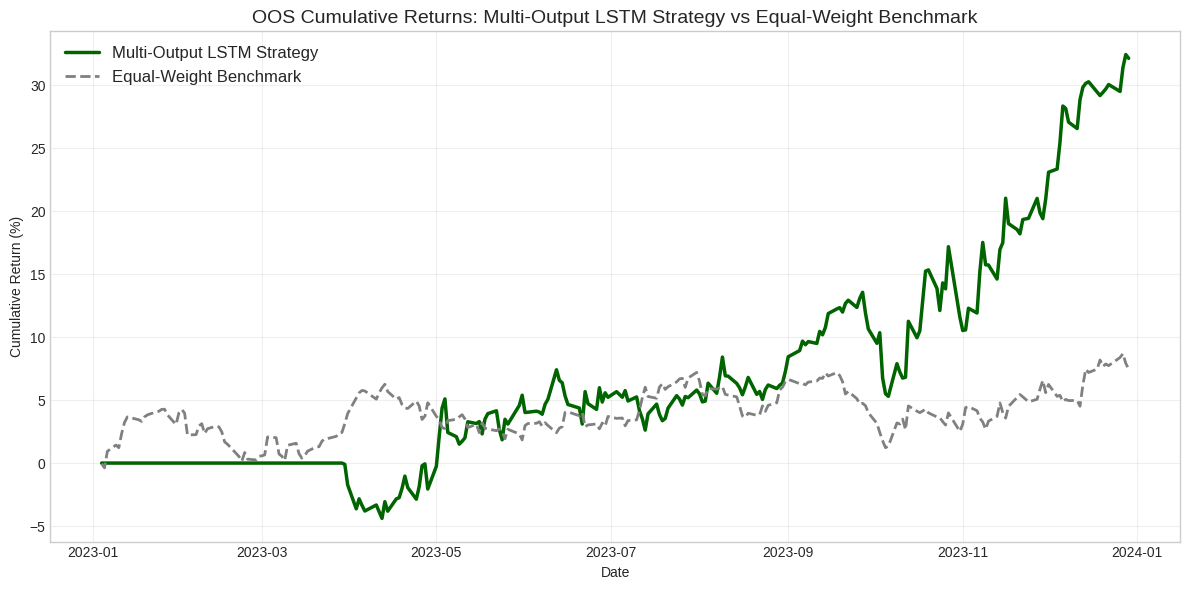

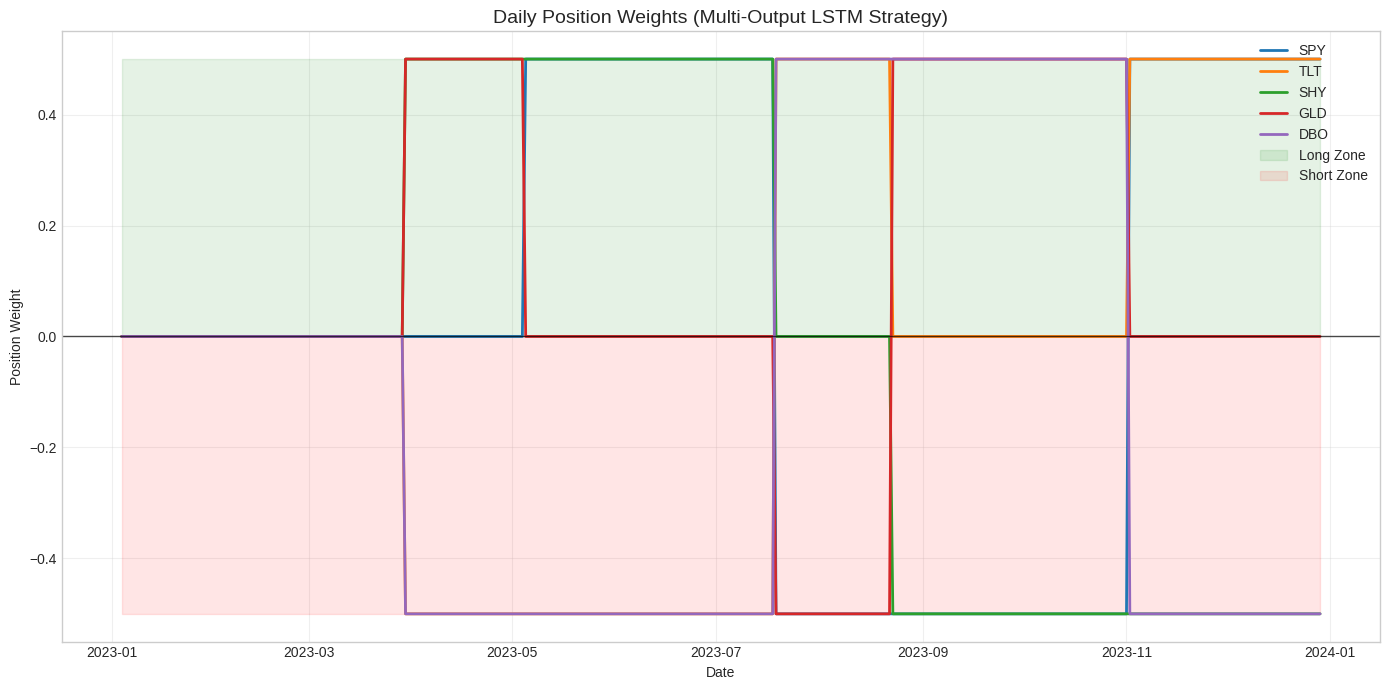


=== Strategy Execution Completed Successfully! ===


In [ ]:
# ----------------------
# Colab Setup & Dependencies (Unchanged)
# ----------------------
%matplotlib inline
import os
import warnings
warnings.filterwarnings('ignore')

# Install dependencies (if missing)
try:
    import yfinance as yf
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.preprocessing import StandardScaler
    import tensorflow as tf
    from tensorflow.keras.models import load_model
except ImportError:
    !pip install yfinance pandas numpy matplotlib seaborn scikit-learn tensorflow --quiet
    import yfinance as yf
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.preprocessing import StandardScaler
    import tensorflow as tf
    from tensorflow.keras.models import load_model

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

# ----------------------
# Reusable Functions (Fixed Prediction Extraction)
# ----------------------
def download_etf_data(etf_symbols, start_date, end_date):
    """Download adjusted closing prices for all 5 ETFs (multi-asset focus)."""
    print(f"Downloading data for {etf_symbols} ({start_date} to {end_date})...")
    data = yf.download(
        tickers=etf_symbols,
        start=start_date,
        end=end_date,
        interval='1d',
        progress=True,
        auto_adjust=False,
        actions=False
    )
    if 'Adj Close' not in data.columns:
        raise ValueError("No 'Adj Close' column found in downloaded data")
    adj_close = data['Adj Close'].dropna()
    print(f"Downloaded: {len(adj_close)} trading days | Columns: {adj_close.columns.tolist()}")
    return adj_close

def calculate_daily_returns(price_data):
    """Calculate log returns for multi-asset data (all 5 ETFs)."""
    returns = np.log(price_data / price_data.shift(1)).dropna()
    print(f"Calculated daily returns: {len(returns)} days | Columns: {returns.columns.tolist()}")
    return returns

def check_multi_output_files():
    """Verify multi-output model and scaler exist (critical for strategy)."""
    print("\n=== Checking for Multi-Output Model/Scaler ===")
    model_path = "multi_output_etf_lstm.h5"
    scaler_path = "multi_output_scaler.npy"
    missing_files = []
    if not os.path.exists(model_path):
        missing_files.append(f"Model: {model_path}")
    if not os.path.exists(scaler_path):
        missing_files.append(f"Scaler: {scaler_path}")
    if missing_files:
        raise FileNotFoundError(
            "Missing required multi-output files (run model training first!):\n" +
            "\n".join(missing_files)
        )
    print("All multi-output files found ✅")
    return model_path, scaler_path

def generate_multi_output_predictions(price_data, rebalance_date, model, scaler, lag_window=60):
    """
    Generate 25-day ahead returns for ALL 5 ETFs using the multi-output model.
    FIX: Extract scalar values from numpy array predictions.
    Args:
        price_data (pd.DataFrame): Adjusted prices for all 5 ETFs
        rebalance_date (pd.Timestamp): Date to generate predictions (no look-ahead)
        model (tf.keras.Model): Trained multi-output LSTM
        scaler (StandardScaler): Fitted scaler from model training
        lag_window (int): 60-day input window (matches model training)
    Returns:
        dict: Predicted 25-day returns for each ETF (key: ETF, value: scalar float)
    """
    # Extract data up to rebalance date (no look-ahead bias)
    data_up_to_rebalance = price_data.loc[:rebalance_date]
    returns_up_to_rebalance = calculate_daily_returns(data_up_to_rebalance)

    # Validate input sequence length
    if len(returns_up_to_rebalance) < lag_window:
        raise ValueError(f"Need {lag_window} days of returns, got {len(returns_up_to_rebalance)}")

    # Prepare joint input sequence (all 5 ETFs, last lag_window days)
    input_seq = returns_up_to_rebalance.tail(lag_window).values  # Shape: (60, 5)
    input_seq_scaled = scaler.transform(input_seq)  # Scale features (multi-asset scaling)
    input_seq_3d = input_seq_scaled.reshape(1, lag_window, 5)  # (samples, time_steps, n_assets)

    # Generate multi-output predictions (order: SPY, TLT, SHY, GLD, DBO)
    predictions = model.predict(input_seq_3d, verbose=0)

    # Map predictions to ETFs (extract scalar from numpy array with .item())
    etf_order = ["SPY", "TLT", "SHY", "GLD", "DBO"]
    predicted_returns = {etf: pred[0].item() for etf, pred in zip(etf_order, predictions)}  # FIX HERE

    return predicted_returns

# ----------------------
# Multi-Output LSTM Trading Strategy (Fixed Prediction Printing)
# ----------------------
def execute_multi_output_trading_strategy(
    oos_start,
    oos_end,
    lag_window=60,
    target_horizon=25,
    transaction_cost=0.001  # 0.1% per rebalance
):
    etf_symbols = ["SPY", "TLT", "SHY", "GLD", "DBO"]

    # Step 1: Validate model/scaler files
    model_path, scaler_path = check_multi_output_files()
    model = load_model(model_path, compile=False)  # Colab compatibility
    scaler = np.load(scaler_path, allow_pickle=True).item()

    # Step 2: Download OOS price data (multi-asset)
    print("\n=== Starting Multi-Output LSTM Trading Strategy ===")
    oos_price_data = download_etf_data(etf_symbols, oos_start, oos_end)
    oos_daily_returns = calculate_daily_returns(oos_price_data)

    # Step 3: Generate rebalance dates (every 25 days, starting from lag_window)
    min_required_days = lag_window + 2 * target_horizon  # Ensure 2+ rebalance periods
    if len(oos_price_data) < min_required_days:
        raise ValueError(f"Insufficient OOS data: Need {min_required_days} days, got {len(oos_price_data)}")

    rebalance_dates = []
    for i in range(lag_window, len(oos_price_data) - target_horizon, target_horizon):
        rebalance_dates.append(oos_price_data.index[i])
    print(f"Generated {len(rebalance_dates)} rebalance dates: {[d.strftime('%Y-%m-%d') for d in rebalance_dates]}")

    if not rebalance_dates:
        raise ValueError("No valid rebalance dates found")

    # Step 4: Generate predictions for each rebalance date
    all_predictions = []
    for idx, rebalance_date in enumerate(rebalance_dates):
        print(f"\n--- Rebalance Date {idx+1}/{len(rebalance_dates)}: {rebalance_date.strftime('%Y-%m-%d')} ---")
        try:
            pred_returns = generate_multi_output_predictions(
                price_data=oos_price_data,
                rebalance_date=rebalance_date,
                model=model,
                scaler=scaler,
                lag_window=lag_window
            )
            all_predictions.append(pred_returns)
            # FIX: Round scalar values (now valid since pred_returns are floats)
            print(f"Predictions: { {k: round(v, 4) for k, v in pred_returns.items()} }")
        except Exception as e:
            print(f"❌ Error generating predictions: {str(e)}")
            raise

    # Step 5: Create position signals (long/short/neutral)
    print("\n=== Generating Position Signals ===")
    position_signals = pd.DataFrame(
        index=oos_daily_returns.index,
        columns=etf_symbols,
        data=0.0  # 0 = neutral, +0.5 = long, -0.5 = short
    )

    # Track transaction costs (deducted on rebalance dates)
    transaction_costs = pd.Series(0.0, index=oos_daily_returns.index)

    for period_idx, (rebalance_date, predictions) in enumerate(zip(rebalance_dates, all_predictions)):
        # Rank ETFs by predicted return (highest → lowest)
        ranked_etfs = sorted(predictions.items(), key=lambda x: x[1], reverse=True)
        ranked_names = [etf for etf, _ in ranked_etfs]

        # Assign positions
        long_etfs = ranked_names[:2]    # Top 2 predicted performers
        short_etfs = ranked_names[-2:]  # Bottom 2 predicted underperformers
        neutral_etf = ranked_names[2]   # Middle ETF (no position)

        # Define period end (next rebalance date or OOS end)
        period_end = rebalance_dates[period_idx+1] if period_idx < len(rebalance_dates)-1 else oos_daily_returns.index[-1]
        period_end = min(period_end, oos_daily_returns.index[-1])  # Stay within OOS range

        # Set position weights
        position_signals.loc[rebalance_date:period_end, long_etfs] = 0.5
        position_signals.loc[rebalance_date:period_end, short_etfs] = -0.5
        position_signals.loc[rebalance_date:period_end, neutral_etf] = 0.0

        # Deduct transaction costs (one-way cost: 0.1% of gross exposure)
        if rebalance_date in transaction_costs.index:
            gross_exposure = 1.0  # Long 100% + Short 100% = 200% gross → 0.1% of 200% = 0.2% total cost
            transaction_costs.loc[rebalance_date] = -gross_exposure * transaction_cost

        print(f"Period {period_idx+1}: Long={long_etfs}, Short={short_etfs}, Neutral={neutral_etf}")

    # Step 6: Calculate strategy returns (including transaction costs)
    print("\n=== Calculating Strategy Performance ===")
    # Daily strategy returns = weighted asset returns + transaction costs
    strategy_daily_returns = (position_signals.shift(1) * oos_daily_returns).sum(axis=1) + transaction_costs

    # Benchmark: Equal-weighted buy-and-hold portfolio (same 5 ETFs)
    benchmark_daily_returns = oos_daily_returns.mean(axis=1)

    # Cumulative returns
    strategy_cumulative = (1 + strategy_daily_returns).cumprod() - 1
    benchmark_cumulative = (1 + benchmark_daily_returns).cumprod() - 1

    # Key performance metrics
    total_strat_return = strategy_cumulative.iloc[-1] * 100 if not strategy_cumulative.empty else 0.0
    total_bench_return = benchmark_cumulative.iloc[-1] * 100 if not benchmark_cumulative.empty else 0.0
    strat_vol = strategy_daily_returns.std() * np.sqrt(252) * 100 if not strategy_daily_returns.empty else 0.0
    bench_vol = benchmark_daily_returns.std() * np.sqrt(252) * 100 if not benchmark_daily_returns.empty else 0.0
    strat_sharpe = (strategy_daily_returns.mean() / strategy_daily_returns.std()) * np.sqrt(252) if strategy_daily_returns.std() != 0 else 0.0
    max_drawdown_strat = (strategy_cumulative / strategy_cumulative.cummax() - 1).min() * 100 if not strategy_cumulative.empty else 0.0
    max_drawdown_bench = (benchmark_cumulative / benchmark_cumulative.cummax() - 1).min() * 100 if not benchmark_cumulative.empty else 0.0

    # Print performance summary
    print("\n=== FINAL STRATEGY PERFORMANCE (OOS Period) ===")
    print(f"OOS Date Range: {oos_daily_returns.index.min().strftime('%Y-%m-%d')} to {oos_daily_returns.index.max().strftime('%Y-%m-%d')}")
    print(f"Total Strategy Return: {total_strat_return:.2f}%")
    print(f"Total Benchmark Return (Equal-Weight): {total_bench_return:.2f}%")
    print(f"Annualized Strategy Volatility: {strat_vol:.2f}%")
    print(f"Annualized Benchmark Volatility: {bench_vol:.2f}%")
    print(f"Strategy Sharpe Ratio (Rf=0%): {strat_sharpe:.2f}")
    print(f"Strategy Maximum Drawdown: {max_drawdown_strat:.2f}%")
    print(f"Benchmark Maximum Drawdown: {max_drawdown_bench:.2f}%")

    # Step 7: Visualizations
    print("\n=== Generating Performance Plots ===")

    # Plot 1: Cumulative Returns (Strategy vs Benchmark)
    plt.figure(figsize=(12, 6))
    plt.plot(strategy_cumulative.index, strategy_cumulative * 100, label='Multi-Output LSTM Strategy', linewidth=2.5, color='darkgreen')
    plt.plot(benchmark_cumulative.index, benchmark_cumulative * 100, label='Equal-Weight Benchmark', linewidth=2, color='gray', linestyle='--')
    plt.title('OOS Cumulative Returns: Multi-Output LSTM Strategy vs Equal-Weight Benchmark', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return (%)')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('multi_output_strategy_vs_benchmark.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Plot 2: Position History (All ETFs)
    plt.figure(figsize=(14, 7))
    for etf in etf_symbols:
        plt.plot(position_signals.index, position_signals[etf], label=etf, linewidth=2)
    plt.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.7)
    plt.fill_between(position_signals.index, 0, 0.5, alpha=0.1, color='green', label='Long Zone')
    plt.fill_between(position_signals.index, -0.5, 0, alpha=0.1, color='red', label='Short Zone')
    plt.title('Daily Position Weights (Multi-Output LSTM Strategy)', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Position Weight')
    plt.legend(fontsize=10, loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('multi_output_position_history.png', dpi=300, bbox_inches='tight')
    plt.show()

    return strategy_daily_returns, position_signals, benchmark_daily_returns

# ----------------------
# Main Execution (OOS Period: 2023)
# ----------------------
if __name__ == "__main__":
    # Configuration (matches multi-output model training)
    OOS_START = "2023-01-01"
    OOS_END = "2023-12-31"
    LAG_WINDOW = 60  # Must match model training
    TARGET_HORIZON = 25  # Must match model training
    TRANSACTION_COST = 0.001  # 0.1% per rebalance

    try:
        strategy_returns, positions, benchmark_returns = execute_multi_output_trading_strategy(
            oos_start=OOS_START,
            oos_end=OOS_END,
            lag_window=LAG_WINDOW,
            target_horizon=TARGET_HORIZON,
            transaction_cost=TRANSACTION_COST
        )
        print("\n=== Strategy Execution Completed Successfully! ===")
    except Exception as e:
        print(f"\n❌ Strategy Execution Failed: {str(e)}")
        import traceback
        traceback.print_exc()

**FootNote**

Advantage for using AI: Needing less time to collect information and to evaluate it for accuracy as compared to using bibliographical research.
